<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/ACIS-2023-New-Zealand/blob/main/safe_triage_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Setup and Imports**

In [37]:
import os
import joblib
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Core data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Model development and tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Feature scaling and preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier

# Handling class imbalance
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,              # Overall discrimination
    average_precision_score,    # Precision-recall performance for imbalanced data
    matthews_corrcoef,          # Balanced correlation-based metric
    confusion_matrix,           # Raw classification layout matrix
    balanced_accuracy_score,    # Accuracy adjusted for class imbalance
    fbeta_score,                # Weighted F-score
    brier_score_loss,           # Calibration / probability quality
    roc_curve,                  # ROC curve points
    precision_recall_curve,     # PR curve points
    precision_score,            # Positive predictive value
    recall_score,               # Sensitivity / TPR
    make_scorer,
    auc
)

from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import CalibratedClassifierCV

In [38]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")

export_png = True
export_pdf = True

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

def safe_name(s: str) -> str:
    return "".join(c if (c.isalnum() or c in "-_") else "_" for c in s).strip("_")

In [39]:
# --- Global constants for reproducibility and configuration ---

RANDOM_STATE = 42
TARGET_COLUMN = 'srb_outcome_30d'
PATIENT_ID_COLUMN = 'subject_id'
FBETA_BETA = 2 # Beta value for F-beta score (F2 prioritizes Recall)
f2_scorer = make_scorer(fbeta_score, beta=FBETA_BETA)

In [40]:
# ============================================================
# Environment and Package Versions
# ============================================================

import sys
import platform

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns

import sklearn
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

print("\nCore libraries:")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

print("\nMachine learning libraries:")
print("scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgb.__version__)
print("LightGBM version:", lgb.__version__)
print("TensorFlow version:", tf.__version__)

# Optional: GPU check
gpus = tf.config.list_physical_devices("GPU")
print("\nGPU available:", len(gpus) > 0)
if gpus:
    for gpu in gpus:
        print("GPU device:", gpu.name)

Python version: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39

Core libraries:
NumPy version: 2.1.3
Pandas version: 2.2.3
Matplotlib version: 3.10.0
Seaborn version: 0.13.2

Machine learning libraries:
scikit-learn version: 1.6.1
XGBoost version: 3.4.1
LightGBM version: 4.6.0
TensorFlow version: 2.20.0

GPU available: True
GPU device: /physical_device:GPU:0


### **Data Loading and Initial Inspection**

In [41]:
# --- Load dataset ---
df = pd.read_csv('bq-results-20260628_.csv')

In [42]:
# Shape (rows, columns)
print("Dataset shape:", df.shape)

Dataset shape: (425011, 57)


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425011 entries, 0 to 425010
Data columns (total 57 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   subject_id                              425011 non-null  int64  
 1   hadm_id                                 425011 non-null  object 
 2   stay_id                                 425011 non-null  int64  
 3   triage_time                             425011 non-null  object 
 4   chiefcomplaint                          425011 non-null  object 
 5   age                                     425011 non-null  int64  
 6   gender                                  425011 non-null  object 
 7   race                                    425011 non-null  object 
 8   language                                425011 non-null  object 
 9   insurance                               425011 non-null  object 
 10  marital_status                          4250

In [44]:
# Check missing values
print(df.isnull().sum().sum())

0


In [45]:
admission_status = df['admission_status'].value_counts().sort_index()
print(admission_status)

admission_status
Admitted           202990
Discharged Home    222021
Name: count, dtype: int64


In [46]:
admission_mapping = {
    "Discharged Home": "discharged",
    "Admitted": "admitted",
}

admission_mapping = {
    "Discharged Home": "discharged",
    "Admitted": "admitted",
}

df["admission_status"] = df["admission_status"].map(admission_mapping)

print(df["admission_status"].value_counts())




admission_status
discharged    222021
admitted      202990
Name: count, dtype: int64


### **Feature Renaming**

In [47]:
# Create a comprehensive mapping dictionary for your entire 50-column dataset
feature_rename_dict = {
    # Presentation Indicators (Chief Complaints from Triage)
    "flag_direct_srb": "CC: Direct SRB / Self-Harm",
    "flag_overdose_or_poisoning": "CC: Overdose / Poisoning",
    "flag_psych_crisis": "CC: Psychiatric Crisis",
    "flag_mood_disturbance": "CC: Mood Disturbance",
    "flag_anxiety_distress": "CC: Anxiety / Distress",
    "flag_psychosis": "CC: Psychosis Symptoms",
    "flag_behavioral_dysregulation": "CC: Behavioral Dysregulation",
    "flag_substance_related": "CC: Substance Use",
    "flag_sleep_disturbance": "CC: Sleep Disturbance",

    # Comorbidities & Medical History (Prior ICD Records)
    "hist_sud": "Hx: Substance Use Disorder",
    "hist_mood": "Hx: Mood Disorder",
    "hist_anxiety": "Hx: Anxiety Disorder",
    "hist_srb": "Hx: Prior Self-Harm/SRB",
    "hist_ptsd": "Hx: PTSD",
    "hist_psychotic_disorder": "Hx: Psychotic Disorder",
    "hist_chronic_pain": "Hx: Chronic Pain",
    "hist_cancer": "Hx: Malignancy / Cancer",
    "prior_admission_count": "Hx: Total Past Admissions",

    # 90-Day Medication Prescriptions
    "prior_90d_ssri_prescription": "Med: SSRI (90d)",
    "prior_90d_snri_prescription": "Med: SNRI (90d)",
    "prior_90d_antipsychotic_prescription": "Med: Antipsychotic (90d)",
    "prior_90d_mood_stabilizer_prescription": "Med: Mood Stabilizer (90d)",
    "prior_90d_psych_med_count": "Med: Total Psych Count (90d)",

    # Encoded Socio-demographics & Clinical Context
    "admission_type": "Encounter: Admission Type",
    "admission_status": "Encounter: Admission Status",
    "marital_status": "Demo: Marital Status",
    "insurance": "Demo: Insurance",
    "gender": "Demo: Gender",
    "age": "Demo: Age",
    "language": "Demo: Language",
    "race": "Demo: Race",

    # Temporal Parameters
    "admission_dayofweek": "Time: Day of Week",
    "is_night_admission": "Time: Night Arrival",
    "is_weekend_admission": "Time: Weekend Arrival",
    "hour_sin": "Time: Hour (Sin)",
    "hour_cos": "Time: Hour (Cos)",
    "month_sin": "Time: Month (Sin)",
    "month_cos": "Time: Month (Cos)",

    # Objective Vitals & Physiology
    "temperature": "Vital: Temperature",
    "heartrate": "Vital: Heart Rate",
    "resprate": "Vital: Resp Rate",
    "o2sat": "Vital: O2 Saturation",
    "sbp": "Vital: SBP",
    "dbp": "Vital: DBP",
    "acuity": "Vital: Acuity Score",
    "shock_index": "Physio: Shock Index",
    "pulse_pressure": "Physio: Pulse Pressure"
}

# Apply the rename directly to your primary dataframe
df.rename(columns=feature_rename_dict, inplace=True)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425011 entries, 0 to 425010
Data columns (total 57 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   subject_id                    425011 non-null  int64  
 1   hadm_id                       425011 non-null  object 
 2   stay_id                       425011 non-null  int64  
 3   triage_time                   425011 non-null  object 
 4   chiefcomplaint                425011 non-null  object 
 5   Demo: Age                     425011 non-null  int64  
 6   Demo: Gender                  425011 non-null  object 
 7   Demo: Race                    425011 non-null  object 
 8   Demo: Language                425011 non-null  object 
 9   Demo: Insurance               425011 non-null  object 
 10  Demo: Marital Status          425011 non-null  object 
 11  Encounter: Admission Type     425011 non-null  object 
 12  Vital: Temperature            425011 non-nul

In [49]:
df.head()

,subject_id,hadm_id,stay_id,triage_time,chiefcomplaint,Demo: Age,Demo: Gender,Demo: Race,Demo: Language,Demo: Insurance,...,Med: Mood Stabilizer (90d),Med: Total Psych Count (90d),rule_based_srb_present,model_eligible,Encounter: Admission Status,Time: Hour (Sin),Time: Hour (Cos),Time: Month (Sin),Time: Month (Cos),srb_outcome_30d
0,13238787,no_stay,35341790,2110-01-11 01:45:00,"Back pain, RESTLESSNESS",37,M,UNKNOWN,UNKNOWN,UNKNOWN,...,0,0,0,1,discharged,2.588190e-01,0.965926,0.5,0.866025,0
1,15350437,20383396.0,39042378,2110-01-11 03:43:00,"Diplopia, Transfer",34,M,WHITE,ENGLISH,OTHER,...,0,0,0,1,admitted,7.071068e-01,0.707107,0.5,0.866025,0
2,13370527,no_stay,35220003,2110-01-11 10:08:00,"Abdominal distention, Nausea, RUQ abdominal pain",43,F,UNKNOWN,UNKNOWN,UNKNOWN,...,0,0,0,1,discharged,5.000000e-01,-0.866025,0.5,0.866025,0
3,14695442,no_stay,34789981,2110-01-11 12:44:00,FINGER AMPUTATION,54,M,UNKNOWN,UNKNOWN,UNKNOWN,...,0,0,0,1,discharged,1.224647e-16,-1.000000,0.5,0.866025,0
4,17195991,23542772.0,38649090,2110-01-11 21:42:00,TRIGGER TO RM 20,61,F,OTHER,ENGLISH,PRIVATE,...,0,0,0,1,admitted,-7.071068e-01,0.707107,0.5,0.866025,0


### **Evaluation Utility Functions**

In [50]:
def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, subset_name):
    """Calculates and returns a dictionary of key classification metrics."""
    metrics = {
        'Model': model_name,
        'Subset': subset_name,
        # Discrimination
        'AUROC': roc_auc_score(y_true, y_pred_proba),
        'AUPRC': average_precision_score(y_true, y_pred_proba),
        # Clinical utility
        'F2-Score': fbeta_score(y_true, y_pred_class, beta=2),
        'Precision': precision_score(y_true, y_pred_class),
        'Recall': recall_score(y_true, y_pred_class),
        # Performance and robustness
        'MCC': matthews_corrcoef(y_true, y_pred_class),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred_class)
    }
    return metrics

In [51]:
# Helper functions for Decision Curve Analysis (DCA)
def calculate_net_benefit(y_true, y_pred_proba, thresholds):
    """Calculates Net Benefit across a range of thresholds."""
    results = []

    # Check for the correct shape of y_pred_proba
    if y_pred_proba.ndim > 1 and y_pred_proba.shape[1] > 1:
        y_pred_proba = y_pred_proba[:, 1]

    for t in thresholds:
        # Triage prediction based on threshold
        y_pred = (y_pred_proba >= t).astype(int)

        # Calculate Confusion Matrix components
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # Total number of observations
        N = len(y_true)

        # Net Benefit calculation: NB = (TP / N) - (FP / N) * (t / (1-t))
        # Where t is the threshold probability (or risk)
        net_benefit = (tp / N) - (fp / N) * (t / (1 - t))

        results.append(net_benefit)

    return np.array(results)

In [52]:
def plot_decision_curve(
    y_true,
    y_pred_proba,
    model_name,
    min_thresh,
    max_thresh,
    optimal_threshold=None,
    out_dir="outputs",
    base_name="decision_curve_analysis"
):
    """
    Plots and saves the Decision Curve Analysis figure:
    Net Benefit vs Threshold Probability.
    """

    # Define thresholds as probabilities
    thresholds = np.linspace(min_thresh, max_thresh, 100)

    # 1. Net benefit for the model
    model_nb = calculate_net_benefit(y_true, y_pred_proba, thresholds)

    # 2. Net benefit for treat-all strategy
    prevalence = np.mean(y_true)
    treat_all_nb = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))

    # 3. Net benefit for treat-none strategy
    treat_none_nb = np.zeros_like(thresholds)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot curves
    ax.plot(
        thresholds * 100,
        model_nb,
        label=f"{model_name}",
        linewidth=3
    )

    ax.plot(
        thresholds * 100,
        treat_all_nb,
        label="Treat All",
        linestyle="--",
        linewidth=2
    )

    ax.plot(
        thresholds * 100,
        treat_none_nb,
        label="Treat None",
        linestyle=":",
        linewidth=2
    )

    # Add optimal threshold line if it lies inside the plotted DCA range
    if optimal_threshold is not None and min_thresh <= optimal_threshold <= max_thresh:
        ax.axvline(
            x=optimal_threshold * 100,
            linestyle="-",
            linewidth=1.5,
            label=f"F{FBETA_BETA} Threshold ({optimal_threshold * 100:.2f}%)"
        )

    ax.set_xlabel("Threshold probability (%)")
    ax.set_ylabel("Net benefit per patient")
    print(
        f"Decision Curve Analysis on Test Set "
        f"({min_thresh * 100:.1f}%–{max_thresh * 100:.1f}% risk range)"
    )

    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlim(min_thresh * 100, max_thresh * 100)

    # Dynamic y-axis limit
    y_min = min(treat_all_nb.min(), treat_none_nb.min(), model_nb.min())
    y_max = max(treat_all_nb.max(), treat_none_nb.max(), model_nb.max())

    ax.set_ylim(
        bottom=y_min * 1.1 if y_min < 0 else y_min - 0.001,
        top=y_max * 1.1 if y_max > 0 else y_max + 0.001
    )

    plt.tight_layout()

    # Save figure
    os.makedirs(out_dir, exist_ok=True)

    png_path = os.path.join(out_dir, f"{base_name}.png")
    pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

    fig.savefig(
        png_path,
        bbox_inches="tight",
        pad_inches=0.02,
        dpi=600
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.02
    )

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    plt.show()

    return fig

### **Predictor and Outcome Definition**

In [53]:
TARGET = "srb_outcome_30d"

FEATURES = [
    # --- Other Symptom Presentation Indicators ---
    "CC: Mood Disturbance",
    "CC: Anxiety / Distress",
    "CC: Psychosis Symptoms",
    "CC: Behavioral Dysregulation",
    "CC: Substance Use",
    "CC: Sleep Disturbance",

    # --- Demographics & Social Factors ---
    "Demo: Age",
    "Demo: Gender",

    # --- Psychiatric Medication History (90-Day window) ---
    "Med: SSRI (90d)",
    "Med: SNRI (90d)",
    "Med: Antipsychotic (90d)",
    "Med: Mood Stabilizer (90d)",
    "Med: Total Psych Count (90d)",

    # --- Clinical Comorbidity & Historical Background ---
    "Hx: Substance Use Disorder",
    "Hx: Mood Disorder",
    "Hx: Anxiety Disorder",
    "Hx: Prior Self-Harm/SRB",
    "Hx: PTSD",
    "Hx: Psychotic Disorder",
    "Hx: Chronic Pain",
    "Hx: Malignancy / Cancer",
    "Hx: Total Past Admissions",

    # --- Objective Vital Signs ---
    "Vital: Temperature",
    "Vital: Heart Rate",
    "Vital: Resp Rate",
    "Vital: O2 Saturation",
    "Vital: SBP",
    "Vital: DBP",
    "Vital: Acuity Score",

    # --- Derived Physiology Metrics ---
    "Physio: Shock Index",
    "Physio: Pulse Pressure",

    # --- Temporal Features ---
    "Time: Night Arrival",
    "Time: Weekend Arrival",
    "Time: Hour (Sin)",
    "Time: Hour (Cos)",
    "Time: Month (Sin)",
    "Time: Month (Cos)"
]

# Structural validation tracking against your final df.info() columns
missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
assert len(missing) == 0, f"Missing columns in current DataFrame structure: {missing}"

# Isolate predictive metrics matrix and target vector (No downsampling yet)
X = df[FEATURES].copy()
y = df[TARGET].astype(int)

print(f"Features matrix shape: {X.shape} (All {X.shape[1]} variables cleanly aligned)")
print(f"Target vector shape:   {y.shape}")

Features matrix shape: (425011, 37) (All 37 variables cleanly aligned)
Target vector shape:   (425011,)


### **Outcome Distribution**

In [54]:
print(df['srb_outcome_30d'].value_counts().sort_index())
print("\n========================================\n")
print(df['srb_outcome_30d'].value_counts(normalize=True) * 100)

srb_outcome_30d
0    416040
1      8971
Name: count, dtype: int64


srb_outcome_30d
0    97.889231
1     2.110769
Name: proportion, dtype: float64


### **Patient-Level Stratified Split**

In [55]:
# Create patient-level stratification (1 row per patient)
by_subj = df.groupby('subject_id')['srb_outcome_30d'].max().rename('subj_label').reset_index()
print("Unique patients:", len(by_subj))


train_ids, test_ids = train_test_split(
    by_subj['subject_id'], test_size=0.20, random_state=42,
    stratify=by_subj['subj_label']
)
train_subj = by_subj[by_subj['subject_id'].isin(train_ids)]
train_ids, val_ids = train_test_split(
    train_subj['subject_id'], test_size=0.20, random_state=42,
    stratify=train_subj['subj_label']
)

# Now filter your main dataset
train = df[df['subject_id'].isin(train_ids)].copy()
val   = df[df['subject_id'].isin(val_ids)].copy()
test  = df[df['subject_id'].isin(test_ids)].copy()

def prev(d): return float(np.mean(d['srb_outcome_30d']))
print(f"\nTrain n={len(train):,} prev={prev(train):.2f} | "
      f"Val n={len(val):,} prev={prev(val):.2f} | "
      f"Test n={len(test):,} prev={prev(test):.2f}")

print("\nUnique patients per split:")
print(f"Train: {train['subject_id'].nunique()} | "
      f"Val: {val['subject_id'].nunique()} | "
      f"Test: {test['subject_id'].nunique()}")

Unique patients: 205465

Train n=270,715 prev=0.02 | Val n=68,794 prev=0.02 | Test n=85,502 prev=0.02

Unique patients per split:
Train: 131497 | Val: 32875 | Test: 41093


In [56]:
# Build X/y for each split
X_train = train.loc[:, FEATURES] # Keep as DataFrame
y_train = train.loc[:, TARGET].to_numpy()

X_val   = val.loc[:, FEATURES]   # Keep as DataFrame
y_val   = val.loc[:, TARGET].to_numpy()

X_test  = test.loc[:, FEATURES]  # Keep as DataFrame
y_test  = test.loc[:, TARGET].to_numpy()

# Quick sanity checks
print("X_train:", X_train.shape, "| y_train:", y_train.shape, "| pos rate:", y_train.mean())
print("\nX_val:  ", X_val.shape,   "| y_val:  ", y_val.shape,   "| pos rate:", y_val.mean())
print("\nX_test: ", X_test.shape,  "| y_test: ", y_test.shape,  "| pos rate:", y_test.mean())

X_train: (270715, 37) | y_train: (270715,) | pos rate: 0.020841105960142586

X_val:   (68794, 37) | y_val:   (68794,) | pos rate: 0.022109486292409223

X_test:  (85502, 37) | y_test:  (85502,) | pos rate: 0.02114570419405394


### **Bootstrap Confidence Interval Function**

In [57]:
def compute_bootstrap_cis(
    y_true,
    y_prob,
    threshold=0.50,
    n_bootstraps=1000,
    alpha=0.95,
    random_state=42
):
    """
    Bootstrap CIs for candidate-model comparison.

    Uses a common fixed classification threshold of 0.50.
    No threshold optimisation is performed.
    """
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    n = len(y_true)

    bootstrapped_metrics = []

    for _ in range(n_bootstraps):

        sample_idx = rng.choice(
            np.arange(n),
            size=n,
            replace=True
        )

        y_b_true = y_true[sample_idx]
        y_b_prob = y_prob[sample_idx]

        if len(np.unique(y_b_true)) < 2:
            continue

        y_b_pred = (
            y_b_prob >= threshold
        ).astype(int)

        auroc = roc_auc_score(
            y_b_true,
            y_b_prob
        )

        auprc = average_precision_score(
            y_b_true,
            y_b_prob
        )

        recall = recall_score(
            y_b_true,
            y_b_pred,
            zero_division=0
        )

        precision = precision_score(
            y_b_true,
            y_b_pred,
            zero_division=0
        )

        f2 = fbeta_score(
            y_b_true,
            y_b_pred,
            beta=2,
            zero_division=0
        )

        mcc = matthews_corrcoef(
            y_b_true,
            y_b_pred
        )

        bal_acc = balanced_accuracy_score(
            y_b_true,
            y_b_pred
        )

        bootstrapped_metrics.append({
            "AUROC": auroc,
            "AUPRC": auprc,
            "F2-Score": f2,
            "Precision": precision,
            "Recall": recall,
            "MCC": mcc,
            "Balanced Accuracy": bal_acc
        })

    boot_df = pd.DataFrame(
        bootstrapped_metrics
    )

    lower_pct = ((1 - alpha) / 2) * 100
    upper_pct = (1 - ((1 - alpha) / 2)) * 100

    summary_results = {}

    for metric in boot_df.columns:

        values = boot_df[metric].dropna()

        median = values.median()

        lower_ci = np.percentile(
            values,
            lower_pct
        )

        upper_ci = np.percentile(
            values,
            upper_pct
        )

        summary_results[metric] = (
            f"{median:.2f} "
            f"({lower_ci:.2f}, {upper_ci:.2f})"
        )

    return summary_results

### **Preprocessing Pipeline**

In [58]:
# --- Identify Categorical Columns to One-Hot Encode ---
categorical_features_to_encode = [
    "Demo: Gender",
]

# --- Identify Continuous Numerical Columns to Scale ---
scale_cols = [
    "Vital: Temperature",
    "Vital: Heart Rate",
    "Vital: Resp Rate",
    "Vital: O2 Saturation",
    "Vital: SBP",
    "Vital: DBP",
    "Physio: Shock Index",
    "Physio: Pulse Pressure",
    "Demo: Age",
    "Med: Total Psych Count (90d)",
    "Hx: Total Past Admissions",
    "Vital: Acuity Score"
]

# --- Identify Remainder Columns to Pass Through Unchanged ---
# (This captures all your binary CC flags and historical Hx flags)
passthrough_cols = [c for c in FEATURES if c not in scale_cols + categorical_features_to_encode]

# --- Single Unified Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_to_encode),
        ('num', StandardScaler(), scale_cols),
        ('pass', 'passthrough', passthrough_cols)
    ],
    remainder='drop'
)

### **Selected Hyperparameter Configuration**

In [59]:
# Final hyperparameter configurations used for model fitting
SAVED_GRID_PARAMS = {
    "Logistic Regression": {
        "classifier__solver": "lbfgs",
        "classifier__penalty": "l2",
        "classifier__C": 10.0
    },
    "Random Forest": {
        "classifier__n_estimators": 300,
        "classifier__min_samples_split": 5,
        "classifier__min_samples_leaf": 8,
        "classifier__max_features": "sqrt",
        "classifier__max_depth": 20
    },
    "XGBoost": {
        "classifier__subsample": 0.8,
        "classifier__n_estimators": 300,
        "classifier__min_child_weight": 5,
        "classifier__max_depth": 6,
        "classifier__learning_rate": 0.1,
        "classifier__gamma": 0,
        "classifier__colsample_bytree": 0.7
    },
    "LightGBM": {
        "classifier__subsample": 0.7,
        "classifier__num_leaves": 31,
        "classifier__n_estimators": 300,
        "classifier__min_child_samples": 20,
        "classifier__max_depth": 10,
        "classifier__learning_rate": 0.05,
        "classifier__colsample_bytree": 0.7
    }
}

### **Candidate Model Training and Evaluation Workflow**

In [60]:
def run_model_workflow(model_type, model_instance, param_grid, preprocessor, X_train, y_train, X_val, y_val, X_test):
    """
    Train and evaluate a candidate model using the predefined hyperparameter
    configuration when available; otherwise perform RandomizedSearchCV.
    """
    results_list = []
    print(f"\n======== Starting {model_type} Workflow ========")

    # Create a base pipeline combining your global preprocessor and current model instance
    full_pipeline = Pipeline(steps=[
          ('preprocessor', preprocessor),
          ('classifier', model_instance)
    ])

    # 1. Hyperparameter Selection / Tuning
    if model_type in SAVED_GRID_PARAMS:
        print(f"Using predefined hyperparameters for {model_type}...")
        # Inject the saved parameters directly into the pipeline
        best_model = full_pipeline.set_params(**SAVED_GRID_PARAMS[model_type])

        print("Fitting model with predefined parameters...")
        best_model.fit(X_train, y_train)
    else:
        print(f"--> No cached parameters found for {model_type}. Initiating Randomized Search...")
        tuner = RandomizedSearchCV(
            estimator=full_pipeline,
            param_distributions=param_grid,
            n_iter=10,
            scoring=f2_scorer,
            cv=3,
            verbose=0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        tuner.fit(X_train, y_train)
        best_model = tuner.best_estimator_
        print(f"Best parameters selected via search: {tuner.best_params_}")

    # 2. Base Model Point Estimates
    print("\n2. Evaluating candidate model performance...")
    datasets = [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]

    for name, X, y in datasets:
        y_pred_proba = best_model.predict_proba(X)[:, 1]
        y_pred_class = (y_pred_proba >= 0.5).astype(int)

        base_results = evaluate_model(y, y_pred_proba, y_pred_class, f"{model_type}", name)
        results_list.append(base_results)

    # 3. Bootstrap Confidence Intervals
    print("\n3. Generating 95% Bootstrap Confidence Intervals...")
    for name, X, y in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
        print(f"Running bootstrap resampling on {name} Set...")
        y_prob = best_model.predict_proba(X)[:, 1]

        ci_metrics = compute_bootstrap_cis(y, y_prob, threshold=0.50,n_bootstraps=1000, random_state=RANDOM_STATE)
        ci_metrics['Model'] = model_type
        ci_metrics['Subset'] = f"{name} (95% CI)"
        results_list.append(ci_metrics)

    print(f"======== Finished {model_type} Workflow ========\n")
    results_df = pd.DataFrame(results_list).round(2)

    return results_df, best_model

### **Logistic Regression Workflow**

In [61]:
lr_param_grid = [
    {
        'classifier__solver': ['liblinear'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': np.logspace(-4, 2, 7)
    },
    {
        'classifier__solver': ['lbfgs'],
        'classifier__penalty': ['l2'],
        'classifier__C': np.logspace(-4, 2, 7)
    },
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': np.logspace(-4, 2, 7)
    }
]

lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=5000)

lr_results_df, lr_best_base_model = run_model_workflow(
    model_type='Logistic Regression',
    model_instance=lr_model,
    param_grid=lr_param_grid,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test
)

display_df = lr_results_df.copy()

metric_cols = [
    "AUROC", "AUPRC", "F2-Score", "Precision", "Recall",
    "MCC", "Balanced Accuracy", "Prevalence"
]

for col in metric_cols:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(
            lambda x: f"{x:.2f}" if isinstance(x, (int, float, np.integer, np.floating)) and not pd.isna(x)
            else x
        )

print("\n--- Logistic Regression Results ---\n")
print(display_df.to_markdown(index=False))

all_results = lr_results_df


======== Starting Logistic Regression Workflow ========
Using predefined hyperparameters for Logistic Regression...
Fitting model with predefined parameters...

2. Evaluating candidate model performance...

3. Generating 95% Bootstrap Confidence Intervals...
Running bootstrap resampling on Validation Set...
Running bootstrap resampling on Test Set...
======== Finished Logistic Regression Workflow ========


--- Logistic Regression Results ---

| Model               | Subset              | AUROC             | AUPRC             | F2-Score          | Precision         | Recall            | MCC               | Balanced Accuracy   |
|:--------------------|:--------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:--------------------|
| Logistic Regression | Train               | 0.81              | 0.14              | 0.24              | 0.06              | 0.73              | 0.17              | 0.75     

### **Random Forest Workflow**

In [62]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_samples_leaf': [2, 4, 8],
    'classifier__min_samples_split': [5, 10, 15],
    'classifier__max_features': ['sqrt', 'log2']
}


rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_results_df, rf_best_base_model = run_model_workflow(
    model_type='Random Forest',
    model_instance=rf_model,
    param_grid=rf_param_grid,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test
)

display_df = rf_results_df.copy()

metric_cols = [
    "AUROC", "AUPRC", "F2-Score", "Precision", "Recall",
    "MCC", "Balanced Accuracy", "Prevalence"
]

for col in metric_cols:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(
            lambda x: f"{x:.2f}" if isinstance(x, (int, float, np.integer, np.floating)) and not pd.isna(x)
            else x
        )

print("\n--- Random Forest Results ---\n")
print(display_df.to_markdown(index=False))

all_results = pd.concat([all_results, rf_results_df], ignore_index=True)


======== Starting Random Forest Workflow ========
Using predefined hyperparameters for Random Forest...
Fitting model with predefined parameters...

2. Evaluating candidate model performance...

3. Generating 95% Bootstrap Confidence Intervals...
Running bootstrap resampling on Validation Set...
Running bootstrap resampling on Test Set...
======== Finished Random Forest Workflow ========


--- Random Forest Results ---

| Model         | Subset              | AUROC             | AUPRC             | F2-Score          | Precision         | Recall            | MCC               | Balanced Accuracy   |
|:--------------|:--------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:--------------------|
| Random Forest | Train               | 0.98              | 0.56              | 0.67              | 0.33              | 0.90              | 0.53              | 0.93                |
| Random Forest | Validation 

### **XGBoost Workflow**

In [63]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

Calculated scale_pos_weight for XGBoost: 46.98


In [64]:
xgb_param_grid = {
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__gamma': [0, 0.2, 1.0],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8],
    'classifier__min_child_weight': [1, 3, 5]
}

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_results_df, xgb_best_base_model = run_model_workflow(
    model_type='XGBoost',
    model_instance=xgb_model,
    param_grid=xgb_param_grid,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test
)

display_df = xgb_results_df.copy()

metric_cols = [
    "AUROC", "AUPRC", "F2-Score", "Precision", "Recall",
    "MCC", "Balanced Accuracy", "Prevalence"
]

for col in metric_cols:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(
            lambda x: f"{x:.2f}" if isinstance(x, (int, float, np.integer, np.floating)) and not pd.isna(x)
            else x
        )

print("\n--- XGBoost Results ---\n")
print(display_df.to_markdown(index=False))

all_results = pd.concat([all_results, xgb_results_df], ignore_index=True)


======== Starting XGBoost Workflow ========
Using predefined hyperparameters for XGBoost...
Fitting model with predefined parameters...

2. Evaluating candidate model performance...

3. Generating 95% Bootstrap Confidence Intervals...
Running bootstrap resampling on Validation Set...
Running bootstrap resampling on Test Set...
======== Finished XGBoost Workflow ========


--- XGBoost Results ---

| Model   | Subset              | AUROC             | AUPRC             | F2-Score          | Precision         | Recall            | MCC               | Balanced Accuracy   |
|:--------|:--------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:--------------------|
| XGBoost | Train               | 0.95              | 0.37              | 0.42              | 0.13              | 0.90              | 0.32              | 0.89                |
| XGBoost | Validation          | 0.82              | 0.16             

### **LightGBM Workflow**

In [65]:
lgbm_param_grid = {
    'classifier__num_leaves': [7, 15, 31],
    'classifier__max_depth': [3, 5, 10, -1],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__min_child_samples': [20, 50, 100],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8]
}


lgbm_model = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgbm_results_df, lgbm_best_base_model = run_model_workflow(
    model_type='LightGBM',
    model_instance=lgbm_model,
    param_grid=lgbm_param_grid,
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test
)

display_df = lgbm_results_df.copy()

metric_cols = [
    "AUROC", "AUPRC", "F2-Score", "Precision", "Recall",
    "MCC", "Balanced Accuracy", "Prevalence"
]

for col in metric_cols:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(
            lambda x: f"{x:.2f}" if isinstance(x, (int, float, np.integer, np.floating)) and not pd.isna(x)
            else x
        )

print("\n--- LightGBM Results ---\n")
print(display_df.to_markdown(index=False))

all_results = pd.concat([all_results, lgbm_results_df], ignore_index=True)


======== Starting LightGBM Workflow ========
Using predefined hyperparameters for LightGBM...
Fitting model with predefined parameters...

2. Evaluating candidate model performance...

3. Generating 95% Bootstrap Confidence Intervals...
Running bootstrap resampling on Validation Set...
Running bootstrap resampling on Test Set...
======== Finished LightGBM Workflow ========


--- LightGBM Results ---

| Model    | Subset              | AUROC             | AUPRC             | F2-Score          | Precision         | Recall            | MCC               | Balanced Accuracy   |
|:---------|:--------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:------------------|:--------------------|
| LightGBM | Train               | 0.91              | 0.27              | 0.33              | 0.10              | 0.83              | 0.25              | 0.83                |
| LightGBM | Validation          | 0.85              | 0.18     

### **Candidate Model Performance**

In [66]:
print(
    "\n======== CANDIDATE MODEL PERFORMANCE: "
    "VALIDATION AND TEST SETS ========\n"
)
final_results = all_results[
    all_results['Subset'].isin(['Validation', 'Test'])
].sort_values(
    by=['Subset', 'AUPRC'],
    ascending=False
)

print(final_results.to_markdown(index=False, floatfmt=".2f"))


======== CANDIDATE MODEL PERFORMANCE: VALIDATION AND TEST SETS ========

| Model               | Subset     |   AUROC |   AUPRC |   F2-Score |   Precision |   Recall |   MCC |   Balanced Accuracy |
|:--------------------|:-----------|--------:|--------:|-----------:|------------:|---------:|------:|--------------------:|
| LightGBM            | Validation |    0.85 |    0.18 |       0.28 |        0.08 |     0.69 |  0.20 |                0.76 |
| XGBoost             | Validation |    0.82 |    0.16 |       0.29 |        0.09 |     0.61 |  0.20 |                0.74 |
| Logistic Regression | Validation |    0.82 |    0.16 |       0.25 |        0.07 |     0.74 |  0.17 |                0.75 |
| Random Forest       | Validation |    0.83 |    0.15 |       0.28 |        0.16 |     0.36 |  0.21 |                0.66 |
| LightGBM            | Test       |    0.83 |    0.17 |       0.27 |        0.08 |     0.69 |  0.19 |                0.76 |
| XGBoost             | Test       |    0.80 |    0

### **Validation-Based Model Selection**

In [67]:
# ------------------------------------------------------------
# Final model selection USING VALIDATION SET ONLY
# ------------------------------------------------------------

validation_point_estimates = all_results[
    (all_results["Subset"] == "Validation")
].copy()

best_model_row = validation_point_estimates.sort_values(
    by=["AUPRC", "F2-Score", "Recall"],
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]

print(
    f"\n========= SELECTED MODEL FOR SAFE-TRIAGE AI: "
    f"{best_model_name} ========="
)

print(f"Validation AUPRC     = {best_model_row['AUPRC']:.2f}")
print(f"Validation F2-Score  = {best_model_row['F2-Score']:.2f}")
print(f"Validation Recall    = {best_model_row['Recall']:.2f}")
print(f"Validation AUROC     = {best_model_row['AUROC']:.2f}")
print(f"Validation MCC       = {best_model_row['MCC']:.2f}")


========= SELECTED MODEL FOR SAFE-TRIAGE AI: LightGBM =========
Validation AUPRC     = 0.18
Validation F2-Score  = 0.28
Validation Recall    = 0.69
Validation AUROC     = 0.85
Validation MCC       = 0.20


In [68]:
# Map the name to the actual model object
if 'Logistic Regression' in best_model_name:
    best_model_obj = lr_best_base_model
elif 'Random Forest' in best_model_name:
    best_model_obj = rf_best_base_model
elif 'XGBoost' in best_model_name:
    best_model_obj = xgb_best_base_model
elif 'LightGBM' in best_model_name:
    best_model_obj = lgbm_best_base_model
else:
    raise ValueError(f"Unrecognized best model name: {best_model_name}")

### **Discrimination Performance Curves**

In [69]:
def plot_roc_curve(
    models,
    X_sklearn,
    title,
    out_dir="outputs",
    base_name="roc_curve"
):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Chance line
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        color='black',
        label='Chance (AUROC = 0.50)'
    )

    for name, model in models:

        y_proba = model.predict_proba(X_sklearn)[:, 1]
        y_true = y_test

        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{name} (AUROC = {roc_auc:.4f})'
        )

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()

    png_path = os.path.join(out_dir, f"{base_name}.png")
    pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

    fig.savefig(
        png_path,
        bbox_inches='tight',
        pad_inches=0.02,
        dpi=600
    )

    fig.savefig(
        pdf_path,
        bbox_inches='tight',
        pad_inches=0.02
    )

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    plt.show()

In [70]:
def plot_pr_curve(models,
                  X_sklearn,
                  title,
                  out_dir="outputs",
                  base_name="precision_recall_curve"):

    fig, ax = plt.subplots(figsize=(8, 6))

    # Baseline prevalence
    baseline = np.mean(y_test)

    ax.plot(
        [0, 1],
        [baseline, baseline],
        linestyle='--',
        color='black',
        label=f'Baseline (AUPRC = {baseline:.4f})'
    )

    for name, model in models:

        y_proba = model.predict_proba(X_sklearn)[:, 1]
        y_true = y_test

        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)

        ax.plot(
            recall,
            precision,
            linewidth=2,
            label=f'{name} (AUPRC = {pr_auc:.4f})'
        )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()

    png_path = os.path.join(out_dir, f"{base_name}.png")
    pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

    fig.savefig(
        png_path,
        bbox_inches="tight",
        pad_inches=0.02,
        dpi=600
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.02
    )

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    plt.show()

Saved PNG: figures/roc_curve_test.png
Saved PDF: figures/roc_curve_test.pdf


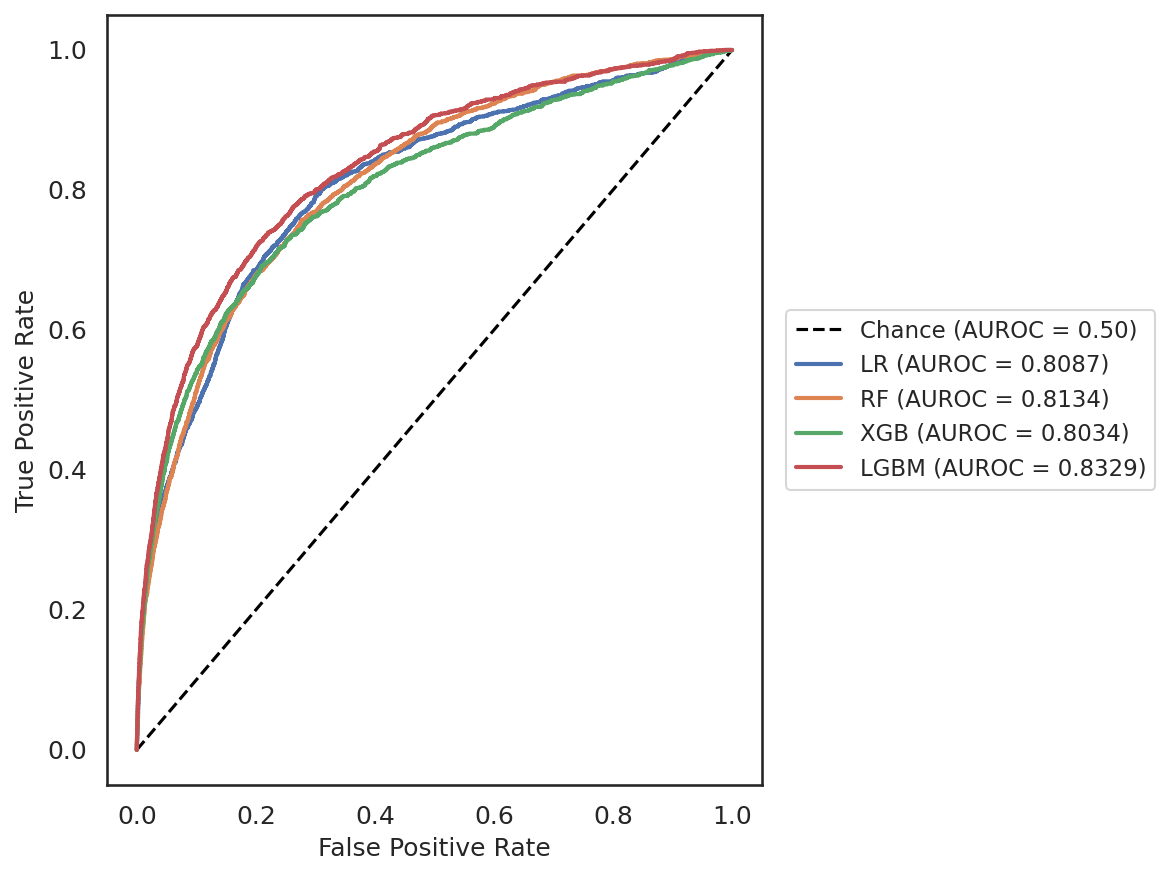

In [71]:
model_comparison = [
    ('LR', lr_best_base_model),
    ('RF', rf_best_base_model),
    ('XGB', xgb_best_base_model),
    ('LGBM', lgbm_best_base_model)
]

plot_roc_curve(
    model_comparison,
    X_test,
    title="ROC Curves on Test Set",
    out_dir=out_dir,
    base_name="roc_curve_test"
)

Saved PNG: figures/pr_curve_test.png
Saved PDF: figures/pr_curve_test.pdf


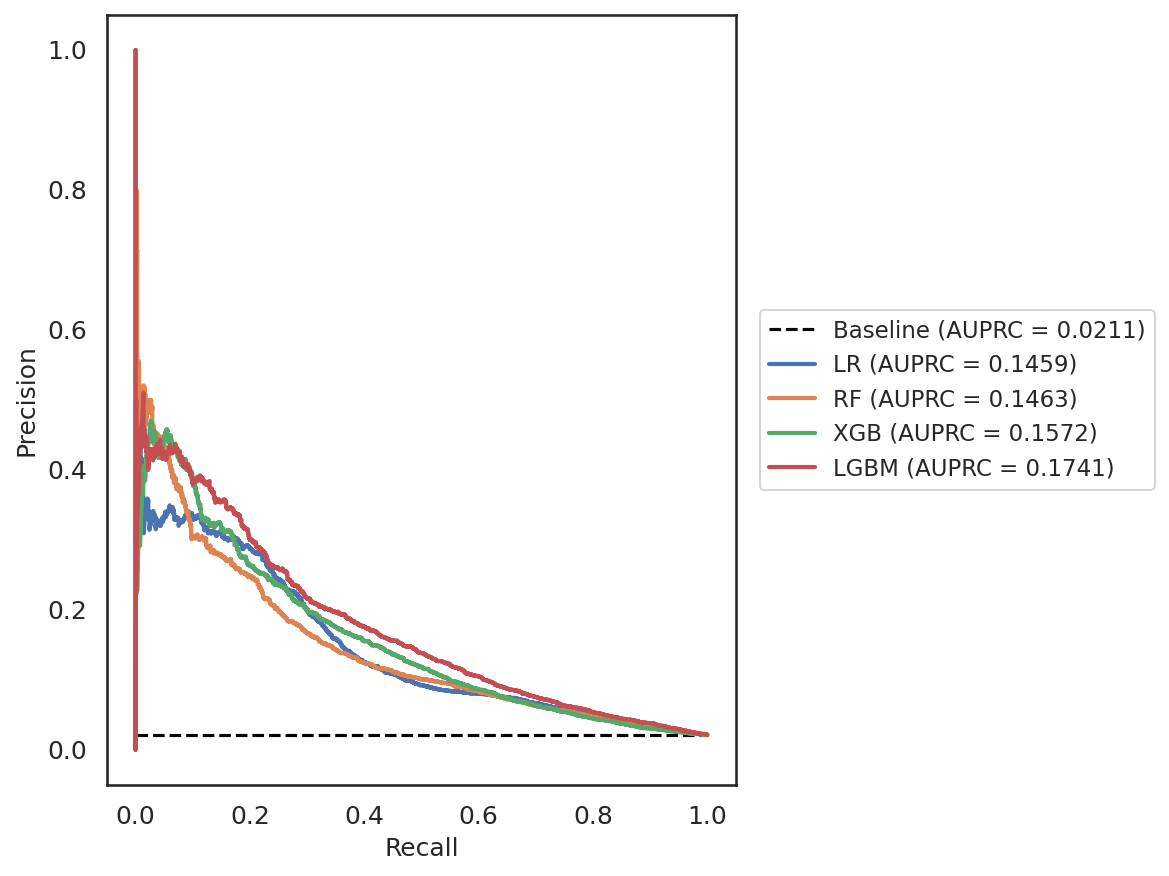

In [72]:
plot_pr_curve(
    model_comparison,
    X_test,
    title='Precision-Recall Curves on Test Set',
    out_dir=out_dir,
    base_name='pr_curve_test'
)

### **Isotonic Calibration and Validation-Based Operating Threshold**

In [73]:
# ============================================================
# Post-Hoc Isotonic Calibration and Validation-Based Threshold
# ============================================================

# 1. Obtain raw probabilities
val_raw_probs = best_model_obj.predict_proba(X_val)[:, 1]
test_raw_probs = best_model_obj.predict_proba(X_test)[:, 1]

# 2. Fit isotonic calibration ONLY on the validation set
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(val_raw_probs, y_val)

# 3. Apply the fitted calibrator
calibrated_val_probs = calibrator.transform(val_raw_probs)
calibrated_test_probs = calibrator.transform(test_raw_probs)

# ============================================================
# Validation-Based Operating-Threshold Selection
# Target sensitivity >= 0.80
# ============================================================

thresholds = np.linspace(0, 1, 10000)

best_clinical_thresh = None
best_val_precision = -1
best_val_recall = None

for t in thresholds:

    val_preds = (calibrated_val_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        val_preds
    ).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Keep highest threshold satisfying sensitivity requirement
    if recall >= 0.80:
        best_clinical_thresh = t
        best_val_recall = recall
        best_val_precision = precision


print("===== Validation-Based Operational Threshold =====")
print(f"Selected calibrated threshold: {best_clinical_thresh:.5f}")
print(f"Validation recall: {best_val_recall:.4f}")
print(f"Validation precision: {best_val_precision:.4f}")


# ============================================================
# LOCK THRESHOLD AND EVALUATE TEST SET ONCE
# ============================================================

test_preds = (
    calibrated_test_probs >= best_clinical_thresh
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_preds
).ravel()

# Metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

precision = ppv
recall = sensitivity

f2 = (
    5 * precision * recall /
    (4 * precision + recall)
    if (4 * precision + recall) > 0
    else 0
)

balanced_acc = (sensitivity + specificity) / 2

mcc = matthews_corrcoef(
    y_test,
    test_preds
)

alerts_per_1000 = (
    (tp + fp) / len(y_test)
) * 1000

missed_srb_rate = (
    fn / (tp + fn)
)

print("\n===== Locked Test-Set Performance =====")

print(f"Threshold: {best_clinical_thresh:.5f}")

print("\nConfusion Matrix:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nPerformance:")
print(f"Sensitivity / Recall: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"PPV / Precision: {ppv:.4f}")
print(f"NPV: {npv:.4f}")
print(f"F2-score: {f2:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"MCC: {mcc:.4f}")

print("\nOperational Burden:")
print(f"Alerts per 1,000 encounters: {alerts_per_1000:.2f}")
print(f"Missed SRB proportion: {missed_srb_rate:.4f}")

===== Validation-Based Operational Threshold =====
Selected calibrated threshold: 0.01730
Validation recall: 0.8166
Validation precision: 0.0571

===== Locked Test-Set Performance =====
Threshold: 0.01730

Confusion Matrix:
TN: 58291
FP: 25403
FN: 360
TP: 1448

Performance:
Sensitivity / Recall: 0.8009
Specificity: 0.6965
PPV / Precision: 0.0539
NPV: 0.9939
F2-score: 0.2124
Balanced Accuracy: 0.7487
MCC: 0.1542

Operational Burden:
Alerts per 1,000 encounters: 314.04
Missed SRB proportion: 0.1991


Calibrated LightGBM Test Set Confusion Matrix (Threshold = 0.01730)


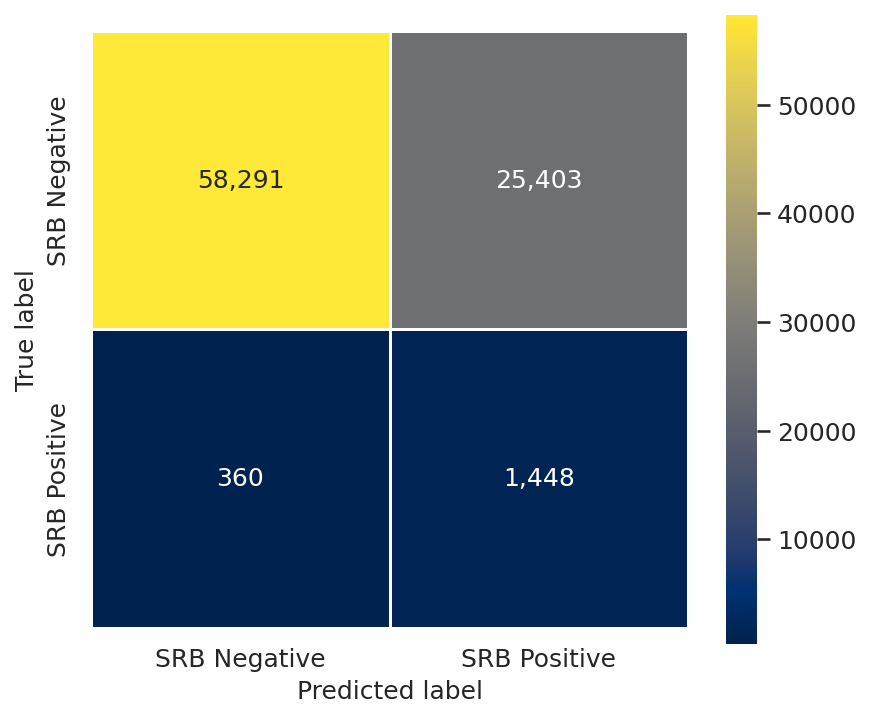

Saved PNG to: plots/cm_optimal_threshold_lightgbm.png
Saved PDF to: plots/cm_optimal_threshold_lightgbm.pdf


In [74]:
cm = np.array([
    [tn, fp],
    [fn, tp]
])

labels = ['SRB Negative', 'SRB Positive']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="cividis",
    xticklabels=labels,
    yticklabels=labels,
    square=True,
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)


print(f"Calibrated LightGBM Test Set Confusion Matrix (Threshold = {best_clinical_thresh:.5f})")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()

out_dir = "plots"
os.makedirs(out_dir, exist_ok=True)

clean_model_name = best_model_name.replace(' ', '_').replace('/', '_').lower()
base_name = f"cm_optimal_threshold_{clean_model_name}"

png_path = os.path.join(out_dir, f"{base_name}.png")
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02, dpi=600)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")


### **Decision Curve Analysis of the Final Calibrated Model**

A Decision Curve Analysis (DCA) evaluates the **clinical utility** of the best model by calculating the **Net Benefit** across a range of threshold probabilities (risks)

*Net Benefit:** Quantifies the net gain (True Positives) minus the harm (False Positives weighted by the threshold risk) that results from using the model for triage decisions.

A model has clinical utility if its curve is **above** both the "Treat All" and "Treat None" strategies.

Decision Curve Analysis on Test Set (0.5%–5.0% risk range)
Saved PNG: plots/decision_curve_analysis_calibrated_test.png
Saved PDF: plots/decision_curve_analysis_calibrated_test.pdf


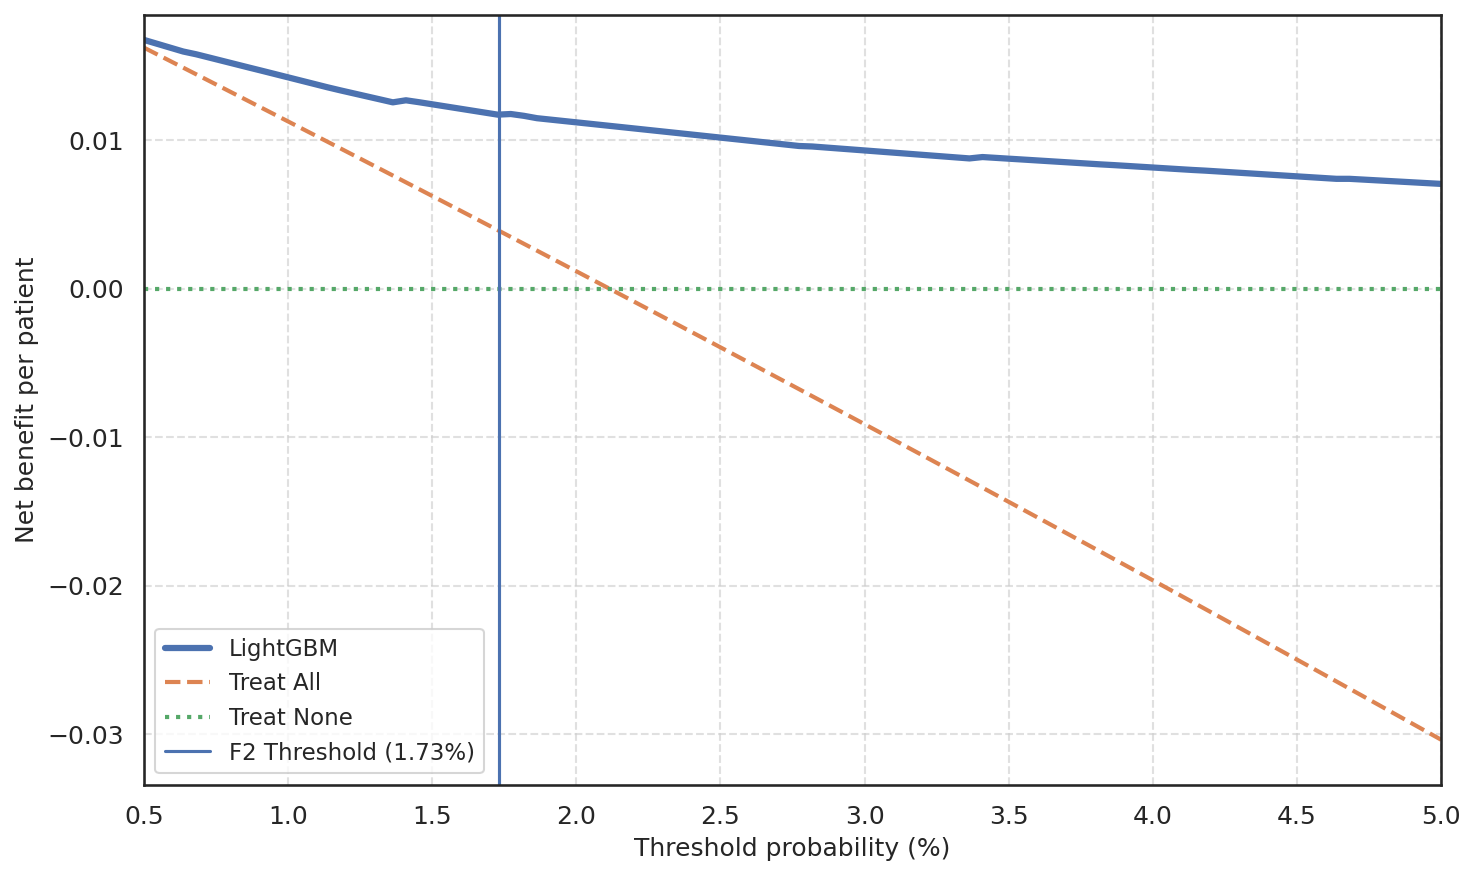


--- Decision Curve Analysis Summary ---
Model: LightGBM
Evaluated threshold-probability range: 0.5%–5.0%
Validation-selected operational threshold: 1.7302%
Decision-curve interpretation should be based on the model's net benefit relative to the Treat-All and Treat-None strategies across the evaluated threshold-probability range.


In [75]:
MIN_THRESHOLD_DCA = 0.005   # 0.5%
MAX_THRESHOLD_DCA = 0.05    # 5%

fig_dca = plot_decision_curve(
    y_true=y_test,
    y_pred_proba=calibrated_test_probs,
    model_name=best_model_name,
    min_thresh=MIN_THRESHOLD_DCA,
    max_thresh=MAX_THRESHOLD_DCA,
    optimal_threshold=best_clinical_thresh,
    out_dir=out_dir,
    base_name="decision_curve_analysis_calibrated_test"
)

print("\n--- Decision Curve Analysis Summary ---")

print(
    f"Model: {best_model_name}"
)

print(
    f"Evaluated threshold-probability range: "
    f"{MIN_THRESHOLD_DCA * 100:.1f}%–"
    f"{MAX_THRESHOLD_DCA * 100:.1f}%"
)

print(
    f"Validation-selected operational threshold: "
    f"{best_clinical_thresh * 100:.4f}%"
)

print(
    "Decision-curve interpretation should be based on the model's "
    "net benefit relative to the Treat-All and Treat-None strategies "
    "across the evaluated threshold-probability range."
)

### **Explainability Analysis of the Selected Model**

In [76]:
import shap

# Ensure reproducibility
shap.initjs()

### **SHAP Explainer Initialization and Computation**

In [77]:
try:
    # -------------------------------
    # 1. Unpack Calibrated Wrapper if Present
    # -------------------------------
    working_model = best_model_obj
    if isinstance(best_model_obj, CalibratedClassifierCV):
        print(f"Detected a CalibratedClassifierCV wrapper. Extracting core architecture...")
        working_model = best_model_obj.estimator

    # -------------------------------
    # 2. Unpack Model Objects if wrapped in a scikit-learn Pipeline
    # -------------------------------
    if isinstance(working_model, Pipeline):
        print(f"Detected a scikit-learn Pipeline wrapper for {best_model_name}. Unpacking components...")

        if 'classifier' in working_model.named_steps:
            raw_model = working_model.named_steps['classifier']
        else:
            raw_model = working_model[-1]

        # Process features using all steps except the final estimator
        X_test_transformed = working_model[:-1].transform(X_test)
        X_train_transformed = working_model[:-1].transform(X_train)

        # Convert back to DataFrame so your SHAP plots have clean, human-readable labels
        if hasattr(working_model[:-1], 'get_feature_names_out'):
            feature_names = working_model[:-1].get_feature_names_out()
            X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)
            X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)
    else:
        # Fallback if it's already a standalone raw estimator
        raw_model = working_model
        X_test_transformed = X_test
        X_train_transformed = X_train

    # -------------------------------
    # 3. Select the appropriate SHAP explainer
    # -------------------------------
    if any(name in best_model_name for name in ['XGBoost', 'Random Forest', 'LightGBM']):
        print(f"Using TreeExplainer for {best_model_name}...")
        explainer = shap.TreeExplainer(raw_model)

        # LightGBM handles pandas DataFrames natively; others prefer raw values
        if 'LightGBM' in best_model_name:
            shap_values = explainer.shap_values(X_test_transformed)
        else:
            shap_values = explainer.shap_values(X_test_transformed.values)

        # Handle formatting anomalies for older/newer SHAP versions
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif len(np.array(shap_values).shape) == 3:
            shap_values = shap_values[:, :, 1]

    elif 'Logistic Regression' in best_model_name:
        print(f"Using LinearExplainer for {best_model_name}...")
        explainer = shap.LinearExplainer(raw_model, X_train_transformed)
        shap_values = explainer.shap_values(X_test_transformed)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        elif len(np.array(shap_values).shape) == 3:
            shap_values = shap_values[:, :, 1]

    else:
        raise ValueError(f"Unsupported model type for SHAP explanation: {best_model_name}")

    # -------------------------------
    # 4. Get expected/base value safely
    # -------------------------------
    expected_value = explainer.expected_value

    if isinstance(expected_value, list):
        expected_value = expected_value[1]
    elif isinstance(expected_value, np.ndarray):
        if expected_value.ndim == 0:
            expected_value = expected_value.item()
        elif len(expected_value) > 1:
            expected_value = expected_value[1]
        else:
            expected_value = expected_value[0]

    print(f"SHAP analysis completed successfully for {best_model_name}.")

except Exception as e:
    print(f"\nSHAP Analysis failed during explainer initialization or SHAP value calculation: {e}")

Detected a scikit-learn Pipeline wrapper for LightGBM. Unpacking components...
Using TreeExplainer for LightGBM...
SHAP analysis completed successfully for LightGBM.


### **Global SHAP Explanations**

Saved PNG: plots/shap_summary_plot.png
Saved PDF: plots/shap_summary_plot.pdf


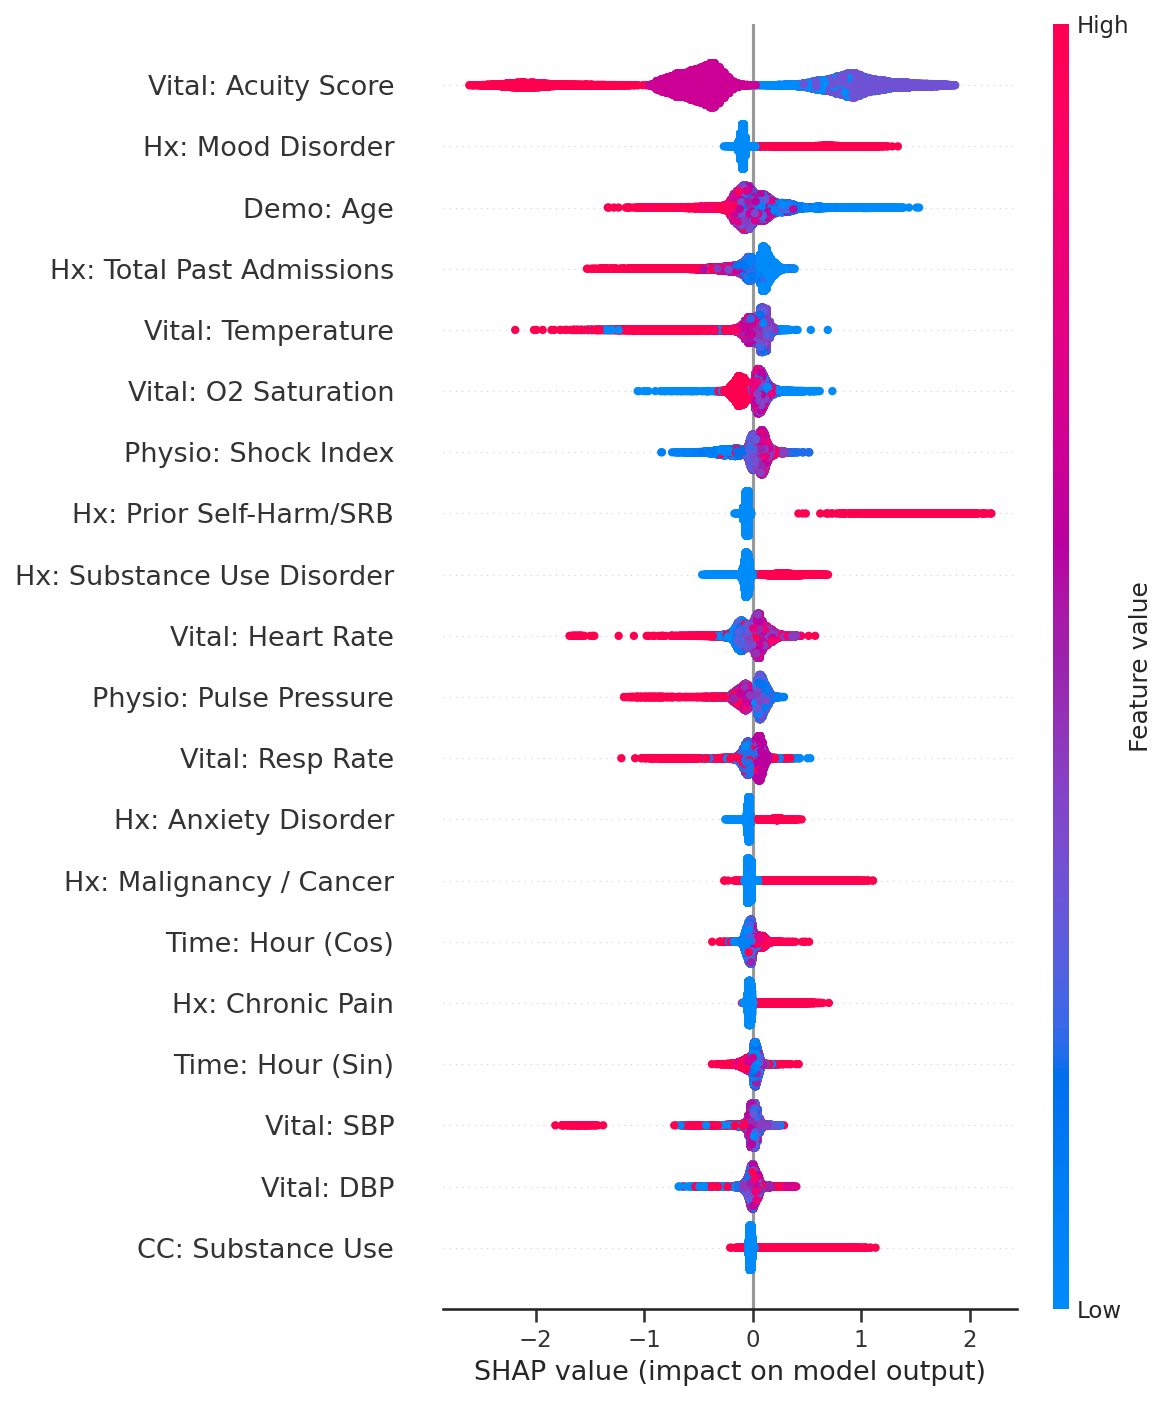

In [78]:
# Strip out "num__" and "cat__" prefixes for professional plot labels
clean_feature_names = [
    col.replace('num__', '').replace('cat__', '').replace('pass__', '')
    for col in X_test_transformed.columns
]

# Update the DataFrame columns directly
X_test_transformed.columns = clean_feature_names

# ==========================================================
# SHAP Summary Plot (Beeswarm)
# ==========================================================
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=X_test_transformed.columns.tolist(),
    plot_type="dot",
    show=False
)

plt.tight_layout()

# Get current figure
fig = plt.gcf()

# ==========================================================
# Save figure
# ==========================================================
base_name = "shap_summary_plot"
png_path = os.path.join(out_dir, f"{base_name}.png")
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

fig.savefig(
    png_path,
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=600
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

plt.show()


Displaying SHAP Feature Importance (Bar Plot - Global Magnitude)...
SHAP Feature Importance (Global Magnitude): LightGBM


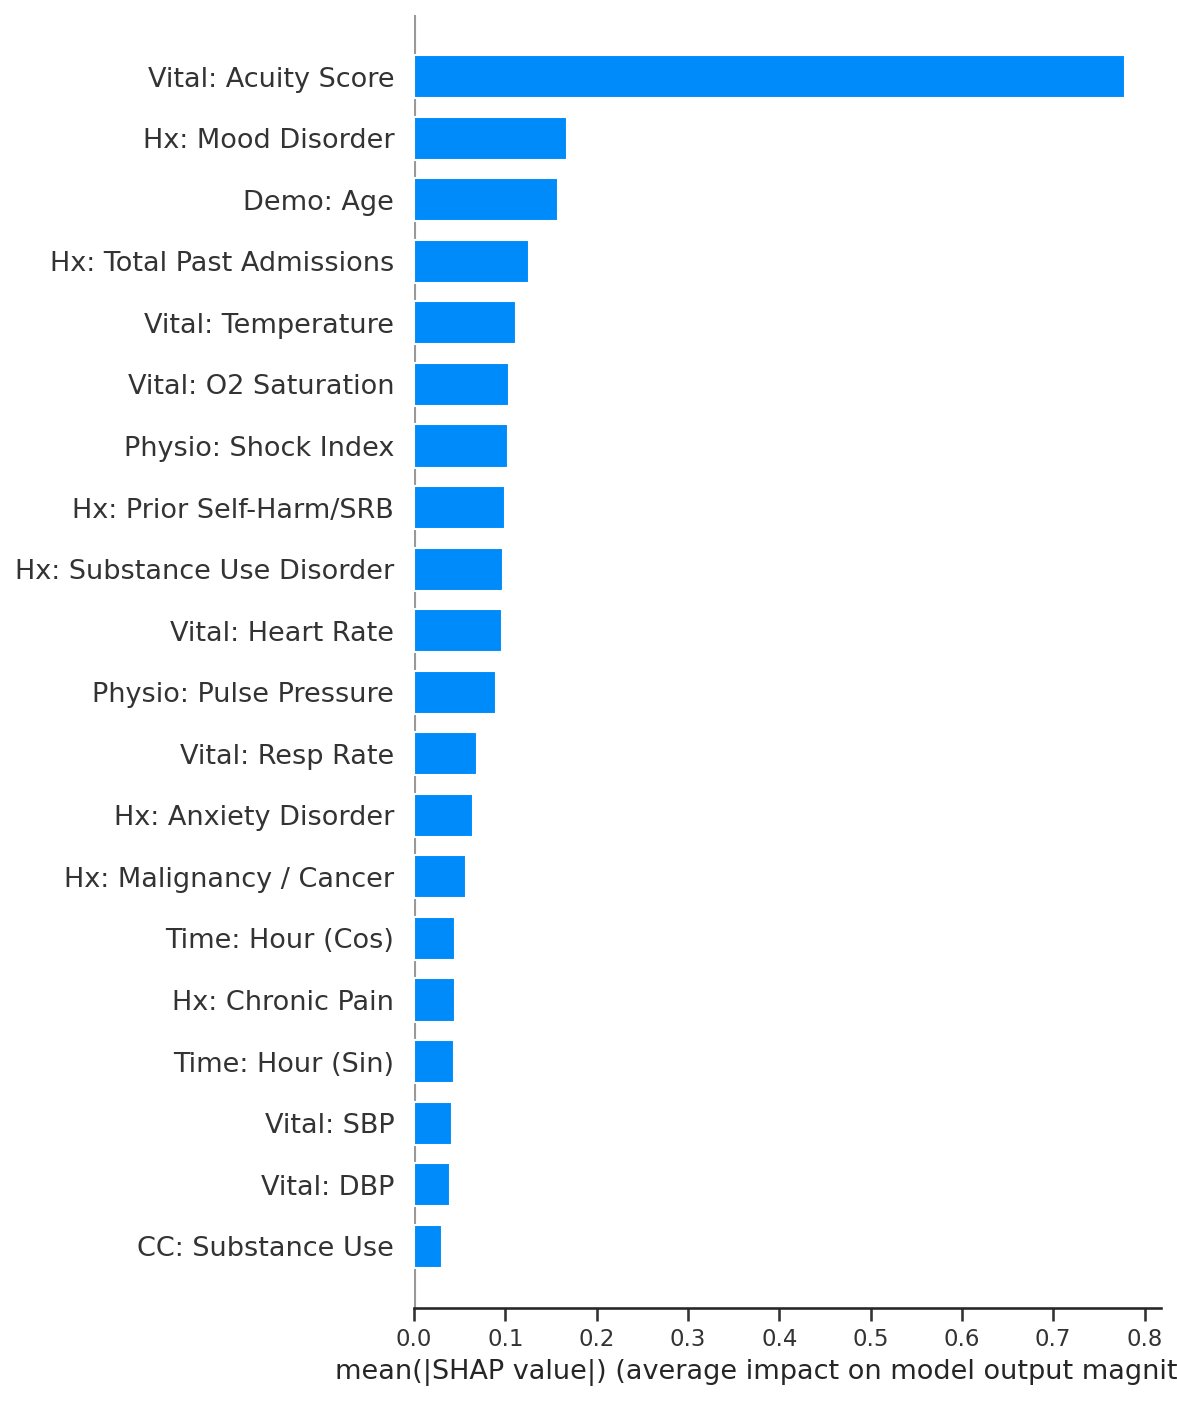

In [79]:
## SHAP Feature Importance (Bar Plot - Global Magnitude)
print("\nDisplaying SHAP Feature Importance (Bar Plot - Global Magnitude)...")

plt.figure(figsize=(12, 8))

# Clean up prefixes on the transformed DataFrame columns (if not already done)
clean_feature_names = [
     col.replace('num__', '').replace('cat__', '').replace('pass__', '')
    for col in X_test_transformed.columns
]
X_test_transformed.columns = clean_feature_names

# Pass the transformed dataset and its corresponding clean columns
shap.summary_plot(
    shap_values,
    X_test_transformed,
    plot_type="bar",
    feature_names=X_test_transformed.columns.tolist(),
    show=False
)

print(f"SHAP Feature Importance (Global Magnitude): {best_model_name}")
fig = plt.gcf()

base_name = "shap_feature_importance"

png_path = os.path.join(out_dir, f"{base_name}.png")
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02, dpi=600)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()

In [80]:
# 1. Extract the raw model out of the Pipeline if necessary
if isinstance(best_model_obj, Pipeline):
    if 'classifier' in best_model_obj.named_steps:
        raw_model = best_model_obj.named_steps['classifier']
    else:
        raw_model = best_model_obj[-1]

    # Use the transformed column names from your preprocessor
    plot_features = X_test_transformed.columns.tolist()
else:
    raw_model = best_model_obj
    plot_features = FEATURES

# 2. Check and print properties on the extracted raw model
if hasattr(raw_model, 'feature_importances_'):
    print(f"\n--- {best_model_name} Gini Feature Importances ---")
    importances = pd.Series(raw_model.feature_importances_, index=plot_features)
    print(importances.sort_values(ascending=False).to_string())

elif hasattr(raw_model, 'coef_'):
    print(f"\n--- {best_model_name} Model Coefficients ---")
    # Handle both 1D and 2D arrays gracefully for linear coefficients
    coef_values = raw_model.coef_[0] if raw_model.coef_.ndim > 1 else raw_model.coef_
    coefficients = pd.Series(coef_values, index=plot_features)
    print(coefficients.sort_values(ascending=False).to_string())

else:
    print(f"Model {best_model_name} does not natively expose feature importances or coefficients.")


--- LightGBM Gini Feature Importances ---
Demo: Age                       956
Vital: Temperature              658
Vital: Heart Rate               655
Physio: Shock Index             642
Vital: SBP                      621
Vital: DBP                      592
Physio: Pulse Pressure          590
Hx: Total Past Admissions       519
Time: Hour (Sin)                370
Time: Hour (Cos)                328
Vital: O2 Saturation            327
Vital: Resp Rate                326
Vital: Acuity Score             273
Time: Month (Sin)               264
Time: Month (Cos)               260
Hx: Prior Self-Harm/SRB         163
Hx: Mood Disorder               134
Hx: Substance Use Disorder      111
CC: Mood Disturbance            109
Hx: Malignancy / Cancer         108
CC: Substance Use               105
Hx: Chronic Pain                100
Demo: Gender_F                   86
Med: Total Psych Count (90d)     81
Hx: Psychotic Disorder           79
Hx: PTSD                         77
CC: Anxiety / Distres

### **Encounter-Level SHAP Explanations**

Single-Patient SHAP Force Plot

In [81]:
# ==========================================================
# Select Illustrative Local SHAP Cases
# Final calibrated SAFE-Triage configuration
# ==========================================================

# Ensure arrays
y_test_arr = (
    y_test.values
    if hasattr(y_test, "values")
    else np.array(y_test)
)

# ----------------------------------------------------------
# Final calibrated probabilities
# ----------------------------------------------------------

# Raw LightGBM probabilities
y_test_raw_proba = best_model_obj.predict_proba(X_test)[:, 1]

# Calibrated probabilities using the validation-fitted calibrator
y_test_calibrated_proba = calibrator.transform(y_test_raw_proba)

# Final operational threshold selected on validation set
final_threshold = best_clinical_thresh

# Final predicted classes
y_test_pred_final = (
    y_test_calibrated_proba >= final_threshold
).astype(int)


# ==========================================================
# Helper function
# ==========================================================

def get_case_index(mask, strategy="highest_probability"):
    indices = np.where(mask)[0]

    if len(indices) == 0:
        return None

    if strategy == "highest_probability":
        return indices[
            np.argmax(y_test_calibrated_proba[indices])
        ]

    elif strategy == "lowest_probability":
        return indices[
            np.argmin(y_test_calibrated_proba[indices])
        ]

    elif strategy == "closest_to_threshold":
        return indices[
            np.argmin(
                np.abs(
                    y_test_calibrated_proba[indices]
                    - final_threshold
                )
            )
        ]

    elif strategy == "random":
        return np.random.default_rng(42).choice(indices)

    else:
        return indices[0]


# ==========================================================
# Define illustrative cases
# ==========================================================

case_indices = {

    # Correct positive:
    # choose strongly positive example
    "true_positive": get_case_index(
        (y_test_arr == 1) &
        (y_test_pred_final == 1),
        strategy="highest_probability"
    ),

    # Incorrect positive:
    # choose strongly positive false alarm
    "false_positive": get_case_index(
        (y_test_arr == 0) &
        (y_test_pred_final == 1),
        strategy="highest_probability"
    ),

    # Correct negative:
    # choose strongly negative example
    "true_negative": get_case_index(
        (y_test_arr == 0) &
        (y_test_pred_final == 0),
        strategy="lowest_probability"
    ),

    # Incorrect negative:
    # choose FN closest to the operational threshold
    "false_negative": get_case_index(
        (y_test_arr == 1) &
        (y_test_pred_final == 0),
        strategy="closest_to_threshold"
    ),

    # Borderline:
    # choose encounter closest to final threshold
    "borderline": get_case_index(
        np.ones_like(y_test_arr, dtype=bool),
        strategy="closest_to_threshold"
    )
}


# ==========================================================
# Display selected cases
# ==========================================================

selected_cases_df = pd.DataFrame([
    {
        "Case": case_name,
        "Index": idx,

        "Subject ID":
            df.loc[X_test.index[idx], "subject_id"]
            if idx is not None else None,

        "Stay ID":
            df.loc[X_test.index[idx], "stay_id"]
            if idx is not None else None,

        "True Label":
            y_test_arr[idx]
            if idx is not None else None,

        "Predicted Label":
            y_test_pred_final[idx]
            if idx is not None else None,

        # Keep both probabilities for transparency
        "Raw Model Probability":
            y_test_raw_proba[idx]
            if idx is not None else None,

        "Calibrated Probability":
            y_test_calibrated_proba[idx]
            if idx is not None else None,

        "Final Threshold":
            final_threshold
    }

    for case_name, idx in case_indices.items()
])

selected_cases_df

,Case,Index,Subject ID,Stay ID,True Label,Predicted Label,Raw Model Probability,Calibrated Probability,Final Threshold
0,true_positive,31179,16015972,30044925,1,1,0.978183,0.702280,0.017302
1,false_positive,32886,17443246,32532687,0,1,0.979205,0.898581,0.017302
2,true_negative,11,13498102,35440868,0,0,0.016711,0.000000,0.017302
3,false_negative,2535,12941398,33979614,1,0,0.361098,0.014229,0.017302
4,borderline,102,15423887,35182866,0,1,0.397984,0.017354,0.017302



Generating SHAP force plot for true_positive | Index: 31179


<Figure size 2700x600 with 0 Axes>

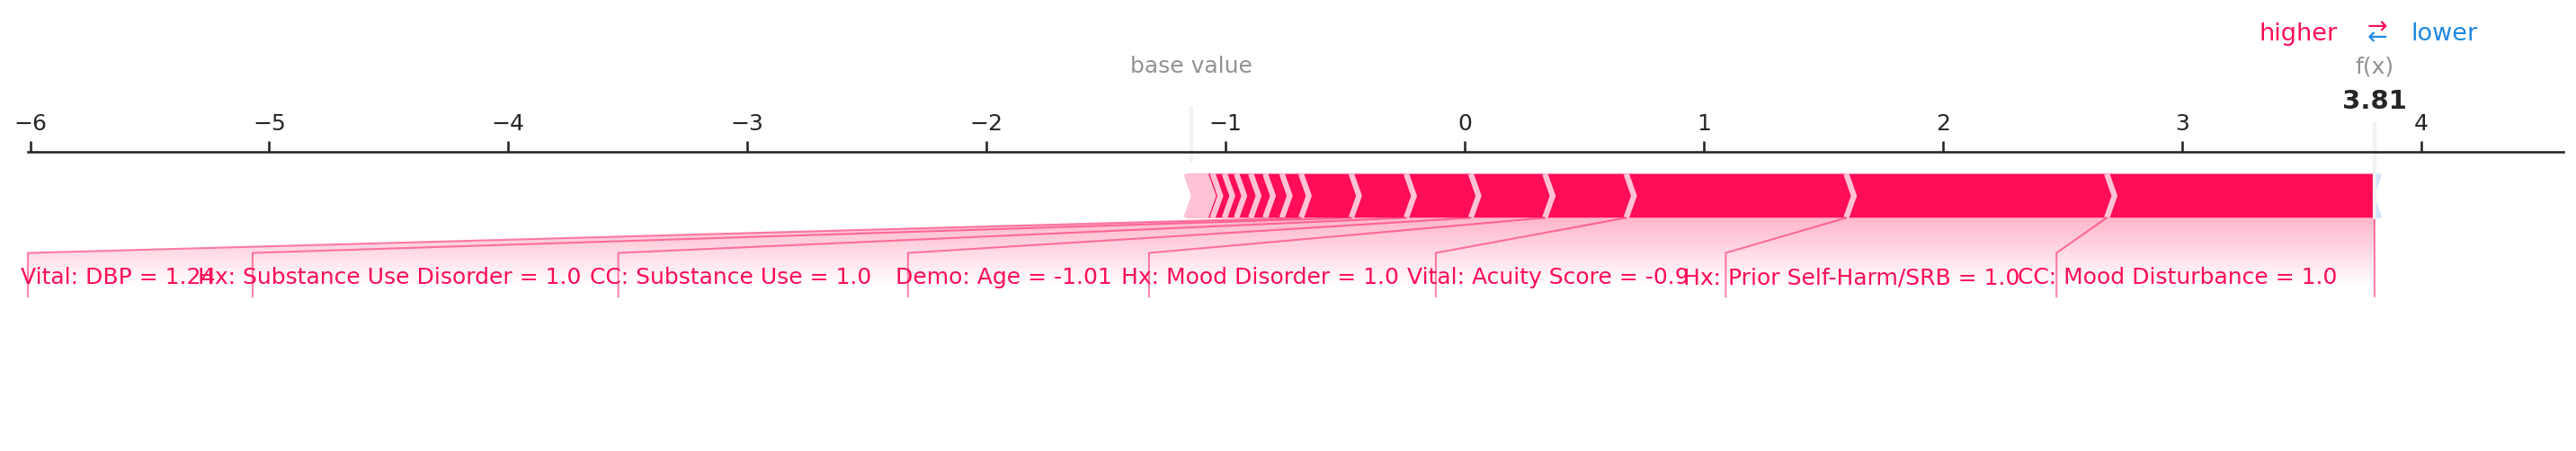

Saved PNG: plots/shap_force_plot_true_positive_index_31179.png
Saved PDF: plots/shap_force_plot_true_positive_index_31179.pdf

Generating SHAP force plot for false_positive | Index: 32886


<Figure size 2700x600 with 0 Axes>

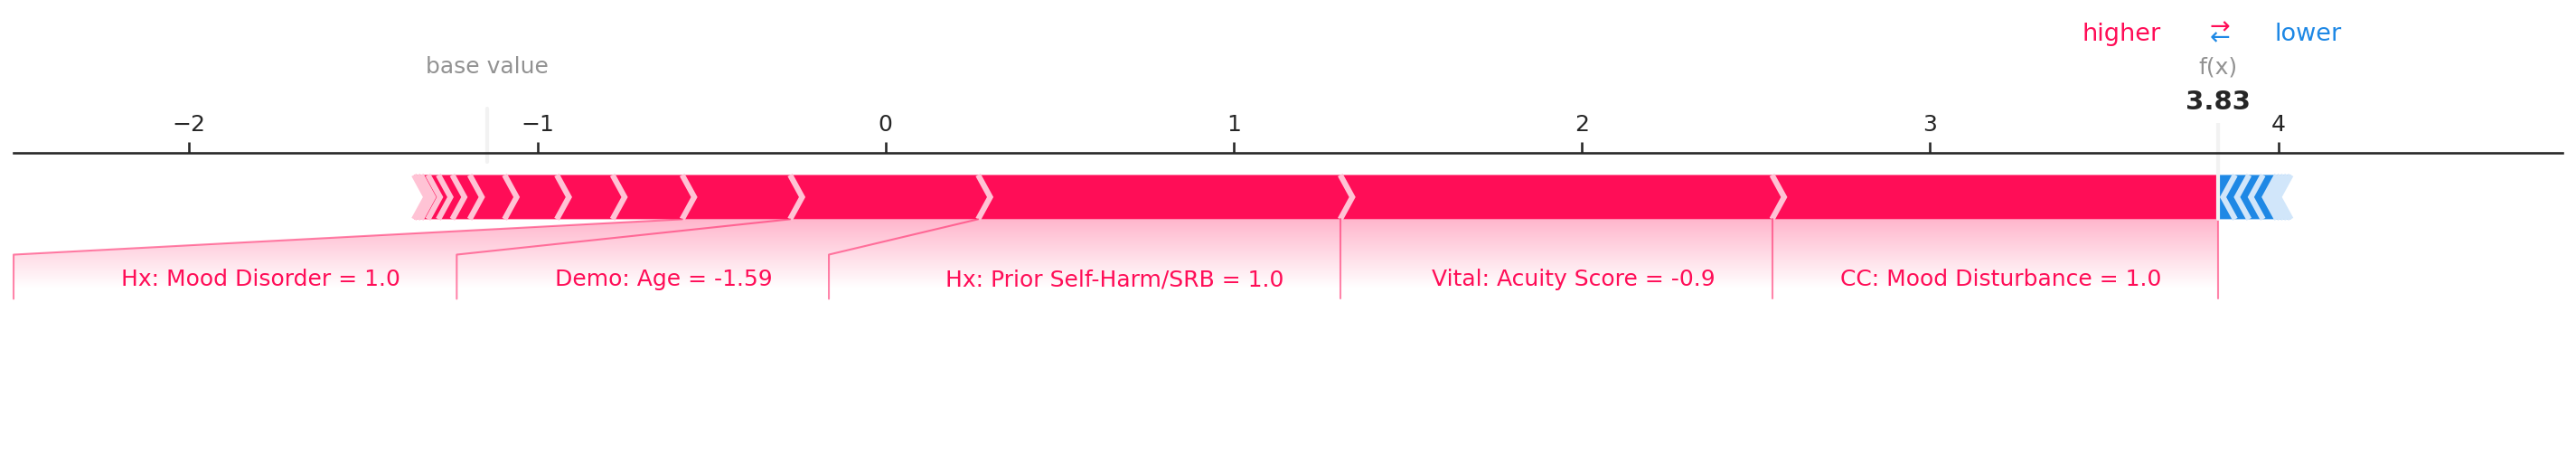

Saved PNG: plots/shap_force_plot_false_positive_index_32886.png
Saved PDF: plots/shap_force_plot_false_positive_index_32886.pdf

Generating SHAP force plot for true_negative | Index: 11


<Figure size 2700x600 with 0 Axes>

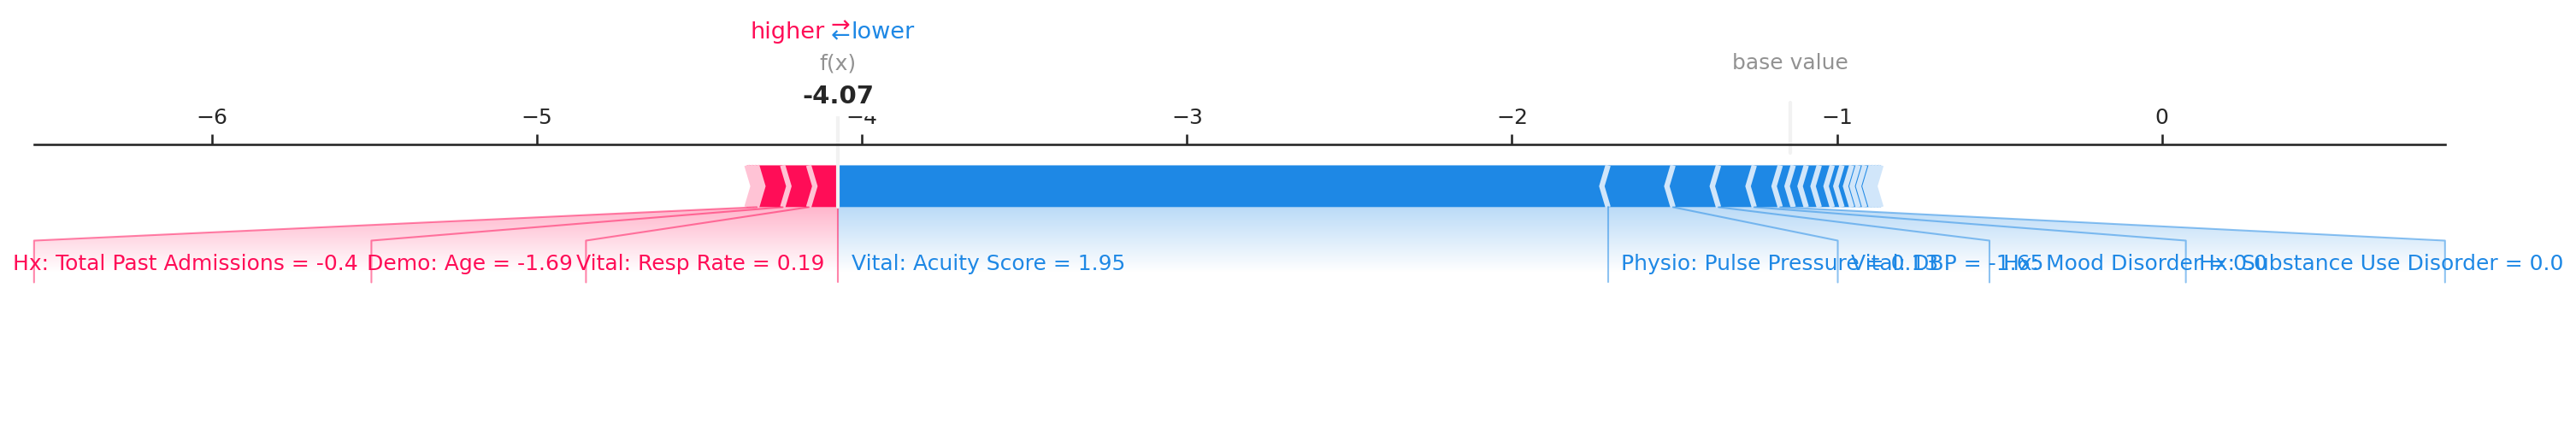

Saved PNG: plots/shap_force_plot_true_negative_index_11.png
Saved PDF: plots/shap_force_plot_true_negative_index_11.pdf

Generating SHAP force plot for false_negative | Index: 2535


<Figure size 2700x600 with 0 Axes>

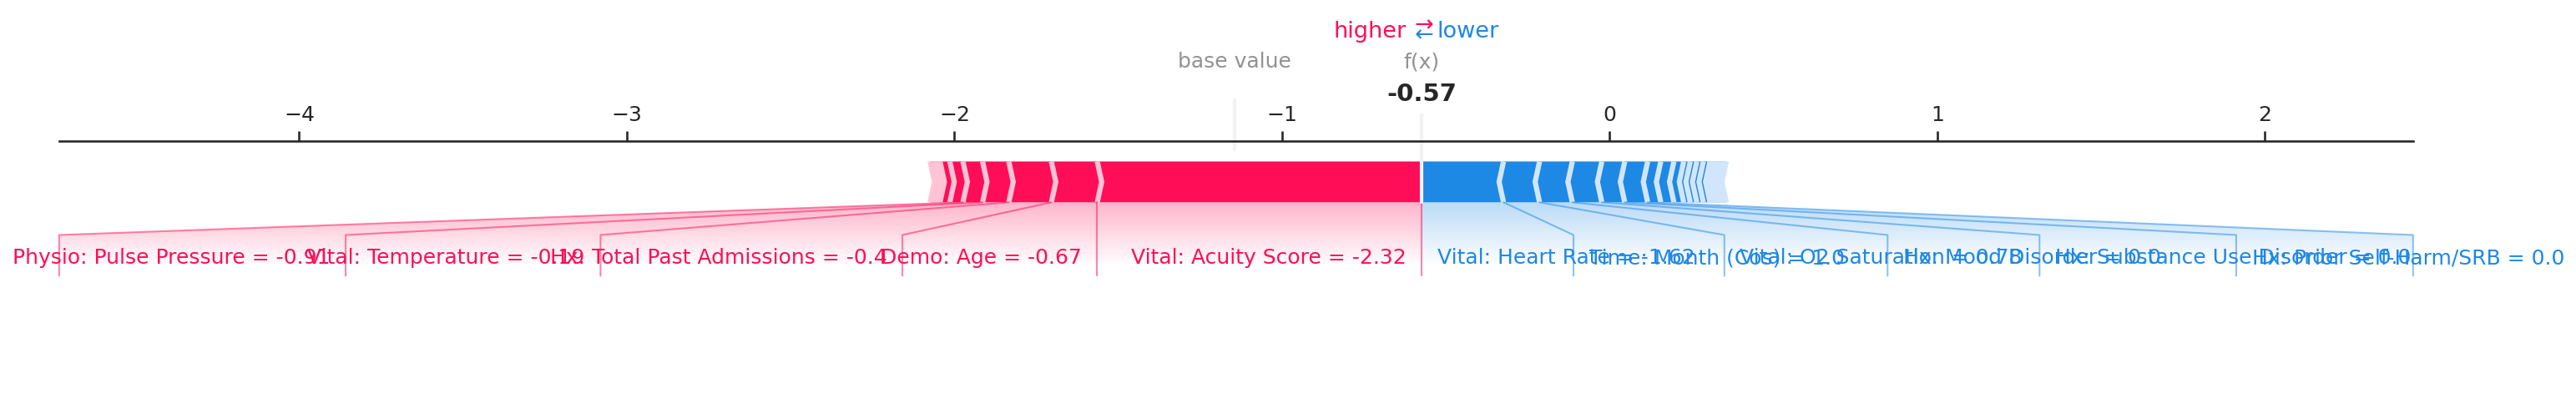

Saved PNG: plots/shap_force_plot_false_negative_index_2535.png
Saved PDF: plots/shap_force_plot_false_negative_index_2535.pdf

Generating SHAP force plot for borderline | Index: 102


<Figure size 2700x600 with 0 Axes>

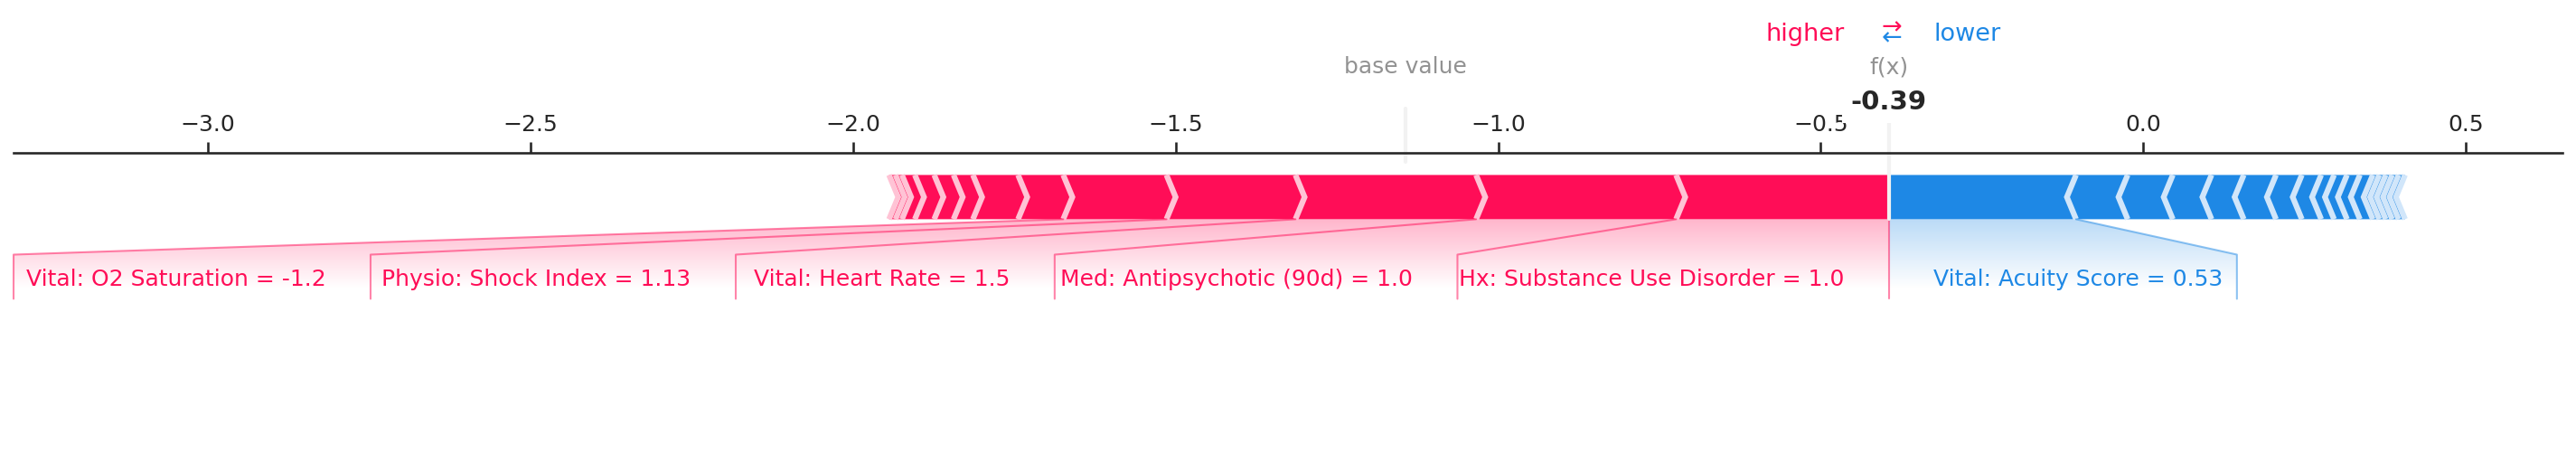

Saved PNG: plots/shap_force_plot_borderline_index_102.png
Saved PDF: plots/shap_force_plot_borderline_index_102.pdf


In [82]:
# ==========================================================
# Generate and Save Local SHAP Force Plots for Selected Cases
# ==========================================================

os.makedirs(out_dir, exist_ok=True)

feature_names_list = X_test_transformed.columns.tolist()

for case_name, idx in case_indices.items():

    if idx is None:
        print(f"Skipping {case_name}: no matching case found.")
        continue

    print(f"\nGenerating SHAP force plot for {case_name} | Index: {idx}")

    X_single_instance = X_test_transformed.iloc[idx]
    shap_values_single_instance = shap_values[idx]

    rounded_X = np.round(X_single_instance.values, 2)
    rounded_shap = np.round(shap_values_single_instance, 2)

    plt.figure(figsize=(18, 4))

    shap.force_plot(
        expected_value,
        rounded_shap,
        rounded_X,
        feature_names=feature_names_list,
        matplotlib=True,
        show=False,
        figsize=(20, 4),
        text_rotation=0
    )

    plt.tight_layout()
    fig = plt.gcf()

    # Give SHAP annotations additional vertical space
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=0.78,
        bottom=0.25
    )

    base_name = f"shap_force_plot_{case_name}_index_{idx}"

    png_path = os.path.join(out_dir, f"{base_name}.png")
    pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

    fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02, dpi=600)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

    plt.show()

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

In [83]:
# ==========================================================
# Local SHAP Reason Table for One Selected Case
# Final calibrated SAFE-Triage configuration
# ==========================================================

def explain_local_case(case_name, idx):
    """
    Builds a local SHAP explanation table for a selected test instance.

    SHAP values explain the underlying LightGBM model output.
    Final classification is based on calibrated probability and the
    validation-selected operational threshold.
    """

    # ------------------------------------------------------
    # Feature values and SHAP values
    # ------------------------------------------------------
    x_row_values = X_test_transformed.iloc[idx].values
    plot_features = X_test_transformed.columns.tolist()

    sv = shap_values[idx]

    # ------------------------------------------------------
    # Raw LightGBM probability
    # ------------------------------------------------------
    raw_prob = best_model_obj.predict_proba(
        X_test.iloc[[idx]]
    )[0, 1]

    # ------------------------------------------------------
    # Calibrated probability
    # ------------------------------------------------------
    calibrated_prob = calibrator.transform(
        np.array([raw_prob])
    )[0]

    # Final classification using validation-selected threshold
    pred_label = int(
        calibrated_prob >= final_threshold
    )

    true_label = y_test_arr[idx]

    # ------------------------------------------------------
    # Local SHAP table
    # ------------------------------------------------------
    df_local = pd.DataFrame({
        "feature": plot_features,
        "value": np.round(x_row_values, 2),
        "shap": np.round(sv, 4),
        "direction": np.where(
            sv >= 0,
            "Increase Model Output (+)",
            "Decrease Model Output (-)"
        )
    })

    df_local["abs_shap"] = df_local["shap"].abs()

    df_local = (
        df_local
        .sort_values(
            "abs_shap",
            ascending=False
        )
        .drop(columns=["abs_shap"])
    )

    # ------------------------------------------------------
    # SHAP model-output reconstruction
    # ------------------------------------------------------
    fx = expected_value + sv.sum()

    # ------------------------------------------------------
    # Print explanation
    # ------------------------------------------------------
    print("\n================ LOCAL REASON CODES ================")

    print(f"Case Type:                       {case_name}")
    print(f"Encounter Position Index:        {idx}")
    print(f"True Label:                      {true_label}")
    print(f"Predicted Label:                 {pred_label}")

    print(
        f"Raw Model Probability:           "
        f"{raw_prob:.4%}"
    )

    print(
        f"Calibrated Probability:          "
        f"{calibrated_prob:.4%}"
    )

    print(
        f"Final Operational Threshold:     "
        f"{final_threshold:.4%}"
    )

    print(
        f"Base Value (Dataset Expectation): "
        f"{expected_value:.4f}"
    )

    print(
        f"Sum of Instance SHAP Values:      "
        f"{sv.sum():.4f}"
    )

    print(
        f"f(x) Output (Base + Sum):         "
        f"{fx:.4f}"
    )

    k = 15

    print(
        f"\nTop {k} Driving Features for "
        f"{case_name} | Encounter  {idx}:\n"
    )

    print(
        df_local
        .head(k)
        .to_markdown(index=False)
    )

    print(
        "\n========================================================\n"
    )

    return df_local

In [84]:
local_explanations = {}

for case_name, idx in case_indices.items():

    if idx is not None:

        local_explanations[case_name] = explain_local_case(
            case_name,
            idx
        )


================ LOCAL REASON CODES ================
Case Type:                       true_positive
Encounter Position Index:        31179
True Label:                      1
Predicted Label:                 1
Raw Model Probability:           97.8183%
Calibrated Probability:          70.2280%
Final Operational Threshold:     1.7302%
Base Value (Dataset Expectation): -1.1442
Sum of Instance SHAP Values:      4.9472
f(x) Output (Base + Sum):         3.8030

Top 15 Driving Features for true_positive | Encounter  31179:

| feature                    |   value |   shap | direction                 |
|:---------------------------|--------:|-------:|:--------------------------|
| CC: Mood Disturbance       |    1    | 1.1232 | Increase Model Output (+) |
| Hx: Prior Self-Harm/SRB    |    1    | 1.0905 | Increase Model Output (+) |
| Vital: Acuity Score        |   -0.9  | 0.9155 | Increase Model Output (+) |
| Hx: Mood Disorder          |    1    | 0.3376 | Increase Model Output (+) |
| Demo: A

### **SAFE-Triage Application Dataset Export**

In [85]:
# ==========================================================
# Create SAFE-Triage Application Database
# Final calibrated deployment configuration
# ==========================================================

# Raw LightGBM probabilities
test_raw_probabilities = best_model_obj.predict_proba(
    test[FEATURES]
)[:, 1]

# Isotonic-calibrated probabilities
test_calibrated_probabilities = calibrator.transform(
    test_raw_probabilities
)

test_db = test.copy()

# Keep raw probability for traceability
test_db["raw_model_probability"] = test_raw_probabilities

# Calibrated probability used for clinician-facing display
test_db["calibrated_probability"] = test_calibrated_probabilities

# Clinician-facing calibrated percentage
test_db["risk_percentage"] = (
    test_calibrated_probabilities * 100
)

# Final SAFE-Triage alert decision
test_db["triage_alert"] = (
    test_calibrated_probabilities >= final_threshold
).astype(int)

# Store threshold for reproducibility/auditability
test_db["operational_threshold"] = final_threshold

test_db.to_csv(
    "safe_triage_app_db.csv",
    index=False
)

### **Deployment Artefact Export**

In [86]:
# Create folder for artefacts
os.makedirs("artefacts", exist_ok=True)

X_background = X_train.sample(
    n=min(1000, len(X_train)),
    random_state=RANDOM_STATE
)

# Save artefacts
joblib.dump(best_model_obj, "artefacts/final_srb_pipeline.joblib")
joblib.dump(best_clinical_thresh, "artefacts/final_threshold.joblib")
joblib.dump(calibrator, "artefacts/final_calibrator.joblib")
joblib.dump(FEATURES, "artefacts/feature_list.joblib")
joblib.dump(explainer, "artefacts/final_shap_explainer.joblib")
joblib.dump(X_background, "artefacts/shap_background.joblib")

print("\nModel artefacts saved successfully:")
print("- artefacts/final_srb_pipeline.joblib")
print("- artefacts/final_threshold.joblib")
print("- artefacts/final_calibrator.joblib")
print("- artefacts/feature_list.joblib")
print("- artefacts/final_shap_explainer.joblib")
print("- artefacts/shap_background.joblib")


Model artefacts saved successfully:
- artefacts/final_srb_pipeline.joblib
- artefacts/final_threshold.joblib
- artefacts/final_calibrator.joblib
- artefacts/feature_list.joblib
- artefacts/final_shap_explainer.joblib
- artefacts/shap_background.joblib
